In [334]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [335]:
pip install statsforecast

Note: you may need to restart the kernel to use updated packages.


In [336]:
# Обработка данных
import pandas as pd
import numpy as np

# Визуализация
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Тесты на стационарность
from statsmodels.tsa.stattools import adfuller, kpss

# Тест на автокорреляцию
from statsmodels.stats.diagnostic import acorr_ljungbox

# Модели ARIMA
from statsmodels.tsa.arima.model import ARIMA

# Модель Prophet
import prophet as fp
from prophet.diagnostics import cross_validation
from prophet.diagnostics import performance_metrics
from prophet.plot import add_changepoints_to_plot

# Декомпозиция
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL as STL_decomp, MSTL as MSTL_decomp

# Настройка
import itertools
from tqdm import tqdm


import warnings
warnings.filterwarnings("ignore")

In [337]:
# авто ARIMA и другие эконометрические модели
from statsforecast import StatsForecast
from statsforecast.models import (
    MSTL,
    AutoARIMA,
    SeasonalNaive,
    HistoricAverage,
    AutoETS,
    AutoTBATS,
    AutoCES,
    AutoTheta,
    HoltWinters
  )


# Оценка качества
from utilsforecast.losses import rmse, mape
from utilsforecast.evaluation import evaluate

In [338]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)

## Шаг 0. Выбор данных и постановка задачи

Для выполнения задания использую датасет Seoul Bike Sharing Demand (https://www.kaggle.com/datasets/saurabhshahane/seoul-bike-sharing-demand-prediction?resource=download), содержащий почасовые данные об аренде велосипедов в Сеуле за 1 год.
Агрегирую данные до дневного уровня и рассматриваю временной ряд:

y — ежедневное количество аренд велосипедов (Rented Bike Count, суммарно за день)

ds — дата

Такой ряд обладает:

- трендом (изменение спроса на велосипеды в течение года)

- как минимум одной выраженной сезонностью — недельной (различия между буднями и выходными).

In [339]:
# Загрузка сырых данных
df_raw = pd.read_csv("SeoulBikeData.csv", encoding="latin1")
df_raw

,Date,Rented Bike Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,30/11/2018,1003,19,4.2,34,2.6,1894,-10.3,0.0,0.0,0.0,Autumn,No Holiday,Yes
8756,30/11/2018,764,20,3.4,37,2.3,2000,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8757,30/11/2018,694,21,2.6,39,0.3,1968,-9.9,0.0,0.0,0.0,Autumn,No Holiday,Yes
8758,30/11/2018,712,22,2.1,41,1.0,1859,-9.8,0.0,0.0,0.0,Autumn,No Holiday,Yes


В исходном датасете данные представлены с часовым шагом. Для упрощения анализа агрегирую данные до дневного уровня: для каждой даты суммирую количество аренд.
Таким образом, шаг времени в анализе 1 день.

In [340]:
# Агрегация до дневного уровня
# В файле дата в формате dd/mm/yyyy, поэтому укажем формат явно
daily = (
    df_raw
    .groupby("Date", as_index=False)["Rented Bike Count"]
    .sum()
)


Поскольку работаю с дневными данными, кандидатами на сезонность являются:

- недельная сезонность (период 7 дней), связанная с различиями между буднями и выходными;

- годовая сезонность (период ≈365 дней), отражающая сезонные изменения спроса (зима/лето).

In [341]:
#Приводим к стандартному формату ds / y
daily["ds"] = pd.to_datetime(daily["Date"], format="%d/%m/%Y")
daily = daily.sort_values("ds")

daily = daily[["ds", "Rented Bike Count"]].rename(
    columns={"Rented Bike Count": "y"}
)

daily

,ds,y
11,2017-12-01,9539
23,2017-12-02,8523
35,2017-12-03,7222
47,2017-12-04,8729
59,2017-12-05,8307
...,...,...
310,2018-11-26,17162
322,2018-11-27,16282
334,2018-11-28,16524
345,2018-11-29,16423


### Шаг 1. Первичный анализ ряда

### Линейный график ряда
На графике ежедневного количества аренд велосипедов в Сеуле видно, что ряд **явно нестационарный**:

- В начале года (зима) уровень спроса относительно низкий — порядка 3–8 тысяч аренд в день.  
  Затем с марта по июнь наблюдается **устойчивый рост** до значений около 25–35 тысяч аренд в день.
- Летом и в начале осени уровень держится на относительно высоких значениях, после чего к концу года спрос постепенно **снижается**.  
  Это соответствует естественному сезонному поведению: в тёплый период велосипеды используют чаще, в холодный — реже.
- На графике видны регулярные волнообразные колебания вокруг общего тренда, что указывает на наличие **повторяющейся сезонной компоненты**. Поскольку данные ежедневные, логично предположить **недельную сезонность** (различия между буднями и выходными).
- Отдельно заметны **резкие провалы до почти нуля** в некоторые дни. Скорее всего, это дни, когда сервис не работал (праздники, техническое обслуживание, экстремальная погода и т.п.). В дальнейшем такие дни могут быть учтены через dummy-регрессоры.

Таким образом, у ряда есть выраженный **тренд** (рост к лету и спад к зиме) и, судя по структуре колебаний, как минимум одна **сезонность с периодом 7 дней**.

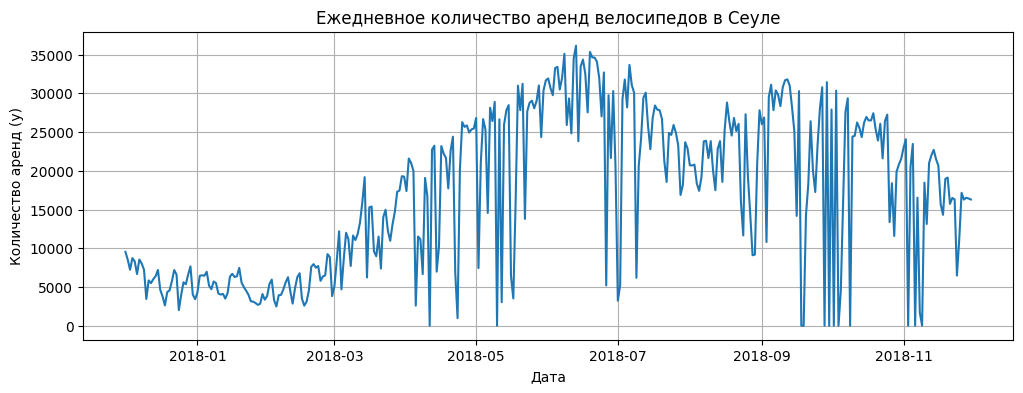

In [342]:
plt.figure(figsize=(12, 4))
plt.plot(daily['ds'], daily['y'])
plt.title('Ежедневное количество аренд велосипедов в Сеуле')
plt.xlabel('Дата')
plt.ylabel('Количество аренд (y)')
plt.grid(True)
plt.show()

### Декомпозиция ряда

Рассмотрела две модели сезонной декомпозиции: аддитивную и мультипликативную.

#### Аддитивная модель

На графиках видно, что:

* **Тренд** плавно растёт от зимы к лету и снижается к осени — это соответствует ожидаемому поведению спроса на велосипеды.
* **Сезональная компонента** с периодом 7 дней имеет примерно **постоянную амплитуду** на протяжении всего года (колебания порядка ±1000–1500 аренд вокруг нуля). Форма сезонности не меняется при изменении уровня ряда.
* **Остатки** распределены вокруг нуля. В середине года, когда уровень спроса самый высокий, разброс остатков немного увеличивается, но сильной гетероскедастичности не наблюдается, основную структуру ряда тренд + недельную сезонность описывают достаточно хорошо.


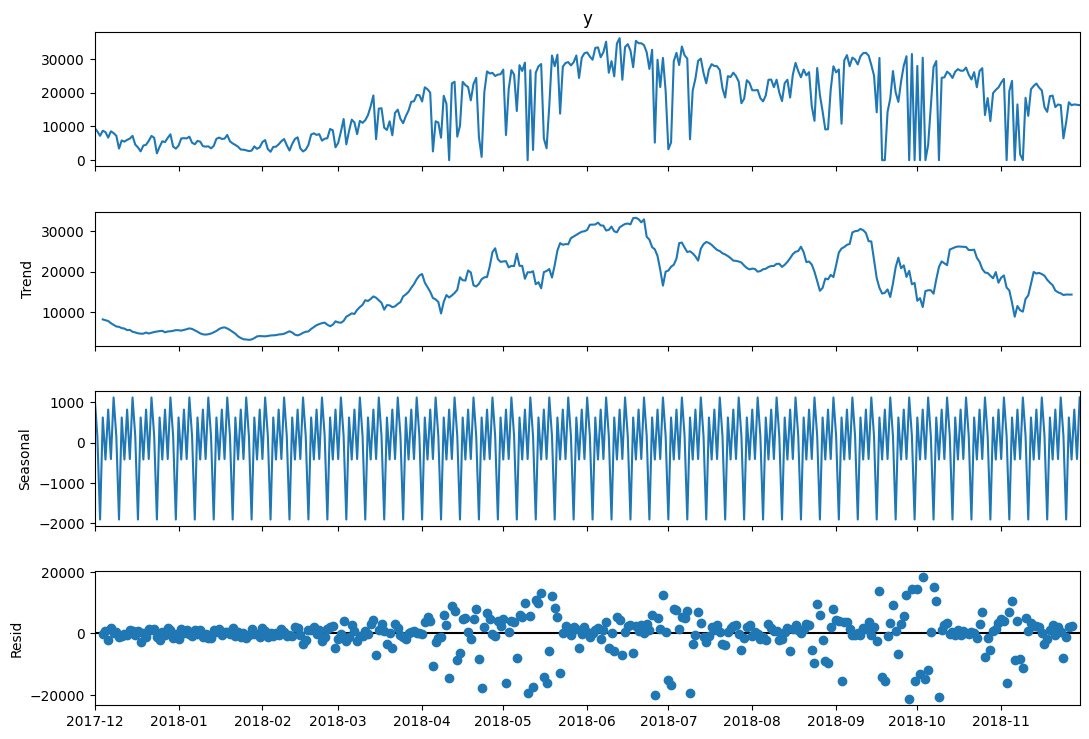

In [343]:
# Убедимся, что индекс по дате
ts = daily.set_index('ds')['y']

# Декомпозиция с недельной сезонностью
decomposition = seasonal_decompose(ts, model='additive', period=7)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()


#### Мультипликативная модель

На соответствующих графиках:

* **Тренд** практически такой же по форме, как в аддитивной модели (рост к лету и спад к осени).
* **Сезональная компонента** колеблется вокруг 1. Это значит, что сезонность интерпретируется как **мультипликативный коэффициент** к тренду: в одни дни недели спрос чуть выше тренда (Seasonal > 1), в другие — чуть ниже (Seasonal < 1).
* **Остатки** на мультипликативной шкале выглядят немного более однородными: при высоком уровне ряда дисперсия остатков стабилизируется лучше, чем в чисто аддитивном разложении, хотя крупные выбросы (дни с почти нулевым спросом) всё равно заметны.


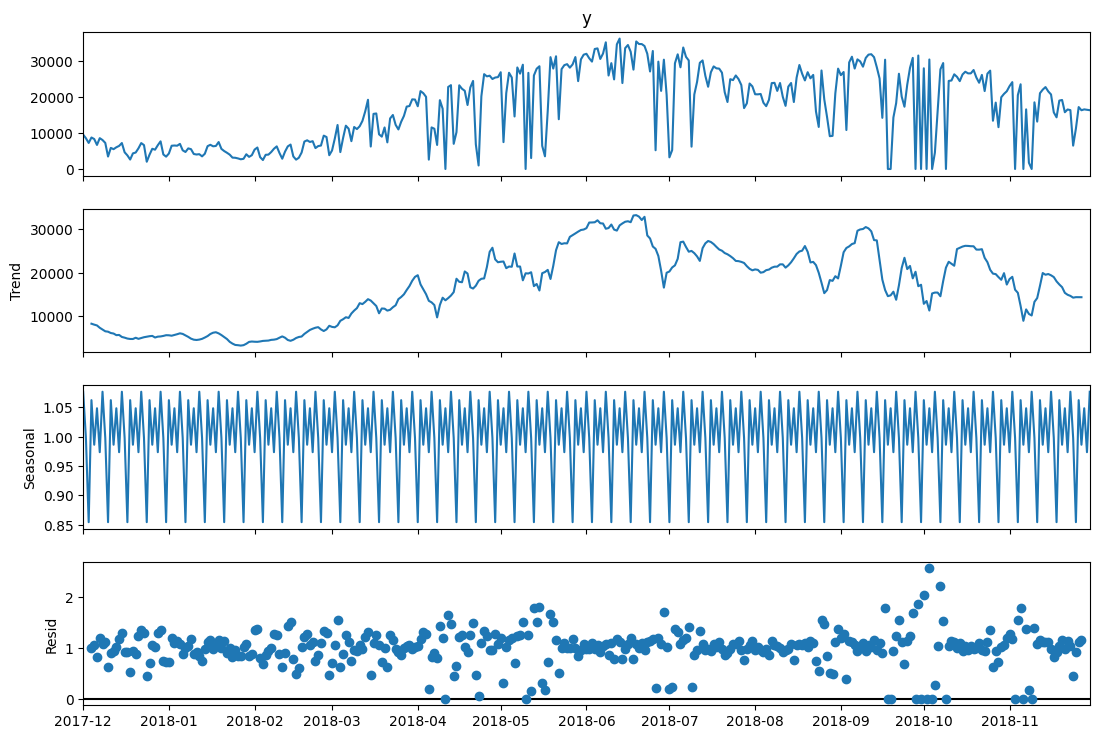

In [344]:
season_length = 7  # длина сезона (например, 7 дней)
ts_pos = ts.copy()
ts_pos[ts_pos <= 0] = 1  # заменяем нули, чтобы избежать проблем

decomposition_mul = seasonal_decompose(
    ts_pos,
    model='multiplicative',
    period=season_length
)

fig = decomposition_mul.plot()
fig.set_size_inches(12, 8)
plt.show()

#### Вывод

В исходных данных амплитуда недельной сезонности на глаз остаётся примерно постоянной и не растёт пропорционально уровню ряда. Поэтому аддитивная модель уже хорошо описывает сезонность.

Мультипликативная декомпозиция даёт схожую форму тренда и сезонности и лишь немного лучше стабилизирует дисперсию остатков. При этом в данных есть дни с очень низкими значениями (почти ноль), что делает чисто мультипликативную модель менее удобной технически.

С учётом этого в дальнейших шагах я буду использовать **аддитивную сезонность** (при необходимости с лог-преобразованием `y` для стабилизации дисперсии), а мультипликативную декомпозицию рассматриваю как дополнительную проверку корректности выбранного подхода.

## Шаг 2. Train/Test = 80/20

Ряд разбит на обучающую и тестовую выборки в пропорции 80/20 по времени.

В результате:

- **train** содержит данные с начала периода до 80% наблюдений
- **test** — последние 20% дат, которые будут использоваться для оценки качества моделей



In [345]:
#Размер выборки
n = len(daily)
print("Всего наблюдений:", n)

#Размер обучающей части (80%)
train_size = int(n * 0.8)
print("Размер train:", train_size)
print("Размер test:", n - train_size)

#разбиение 
train = daily.iloc[:train_size].copy()
test  = daily.iloc[train_size:].copy()

print("Train:", train['ds'].min(), "->", train['ds'].max())
print("Test :", test['ds'].min(), "->", test['ds'].max())


Всего наблюдений: 365
Размер train: 292
Размер test: 73
Train: 2017-12-01 00:00:00 -> 2018-09-18 00:00:00
Test : 2018-09-19 00:00:00 -> 2018-11-30 00:00:00


### Проверка разбиения с помощью визуализации

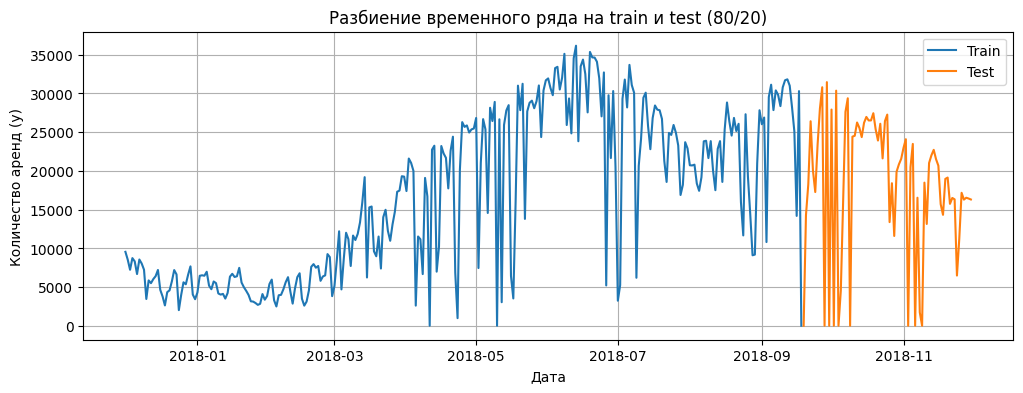

In [346]:
plt.figure(figsize=(12, 4))
plt.plot(train['ds'], train['y'], label='Train')
plt.plot(test['ds'], test['y'], label='Test')
plt.title('Разбиение временного ряда на train и test (80/20)')
plt.xlabel('Дата')
plt.ylabel('Количество аренд (y)')
plt.legend()
plt.grid(True)
plt.show()


## Шаг 3. Подготовка регрессоров (dummy + непрерывный)

### Создаём dummy-признаки на уровне часов

Для моделей с экзогенными признаками использую следующий набор регрессоров:

- **`is_weekend` (dummy)** — индикатор выходного дня (суббота/воскресенье).
  - Поведение пользователей сильно зависит от того, будний это день или выходной.
  - В будни велосипеды чаще используют как транспорт (дорога на работу/учёбу), в выходные для отдыха, поэтому недельная сезонность хорошо описывается через этот признак.

- **`is_holiday` (dummy)** — индикатор календарного праздника.
  - Праздники отличаются от обычных дней как по рабочему статусу, так и по образу жизни людей (выходные, массовые мероприятия, поездки).
  - В такие дни структура спроса на велосипеды меняется: часть людей не едет на работу, кто-то наоборот чаще гуляет. Признак помогает моделям корректно учитывать эти аномальные дни.

- **`is_functioning_day` (dummy)** — индикатор того, работает ли сервис в этот день.
  - В датасете есть дни с резкими провалами количества аренд почти до нуля.
  - Логично предположить, что это дни, когда прокат формально не функционирует (например, техническое обслуживание или официальное закрытие).
  - Этот регрессор помогает моделям не пытаться «объяснить» нулевой спрос трендом или сезонностью и снижает влияние таких дней на оценку параметров.

- **`temp` (Temperature, непрерывный регрессор)** — среднесуточная температура.
  - Спрос на велопрокат напрямую зависит от погоды: при комфортной температуре (весна/лето) люди чаще используют велосипеды, при сильном холоде или жаре — реже.
  - Температура даёт модели информацию о долгосрочной и внутригодовой сезонности (зима -> лето -> зима), дополняя календарные эффекты.

- **`humidity` (Humidity, непрерывный регрессор)** — среднесуточная влажность.
  - Влажность косвенно отражает погодные условия (дождь, сырость, туман), при которых кататься на велосипеде менее приятно.
  - В сочетании с температурой этот признак позволяет лучше описать влияние «плохой погоды» на спрос.

Таким образом, набор регрессоров покрывает:
- **календарные эффекты** (будни/выходные, праздники)
- **фактическую доступность сервиса** (работает / не работает)
- **погодные факторы** (температура и влажность)



In [347]:
# Преобразуем признак Holiday в dummy: 1 = праздник, 0 = обычный день
df_raw['is_holiday'] = (df_raw['Holiday'] != 'No Holiday').astype(int)

# Преобразуем Functioning Day в dummy: 1 = день, когда сервис работает
df_raw['is_functioning_day'] = (df_raw['Functioning Day'] == 'Yes').astype(int)


### Агрегируем погодные и dummy-признаки до дневного уровня (как таргет)

In [348]:
# Агрегация до дневного уровня: средняя погода + флаги по дням
reg_daily = (
    df_raw
    .groupby('Date', as_index=False)
    .agg({
        'Temperature(°C)': 'mean',    # непрерывный регрессор
        'Humidity(%)': 'mean',        # можно использовать как доп. непрерывный
        'is_holiday': 'max',          # если хотя бы один час был праздником -> день праздник
        'is_functioning_day': 'max'   # если сервис работал хотя бы в один час ->  день функционирующий
    })
)

# Приводим к тому же формату дат, что и в daily
reg_daily['ds'] = pd.to_datetime(reg_daily['Date'], format='%d/%m/%Y')
reg_daily = reg_daily.drop(columns=['Date'])
reg_daily.head()


,Temperature(°C),Humidity(%),is_holiday,is_functioning_day,ds
0,-1.283333,39.333333,1,1,2018-01-01
1,-3.866667,44.000000,0,1,2018-02-01
2,0.450000,64.208333,1,1,2018-03-01
3,15.183333,68.916667,0,1,2018-04-01
4,20.341667,72.791667,1,1,2018-05-01


### Добавляем календарный dummy is_weekend

In [349]:
# Добавляем флаг выходного дня (суббота/воскресенье)
reg_daily['is_weekend'] = reg_daily['ds'].dt.weekday.isin([5, 6]).astype(int)


### Объединяем регрессоры с основным рядом daily

In [350]:
#Соединяем таргет y и регрессоры по дате
df = daily.merge(reg_daily, on='ds', how='left')

#Для удобства переименуем непрерывные регрессоры
df = df.rename(columns={
    'Temperature(°C)': 'temp',
    'Humidity(%)': 'humidity'
})

df.head()


,ds,y,temp,humidity,is_holiday,is_functioning_day,is_weekend
0,2017-12-01,9539,-2.454167,45.875000,0,1,0
1,2017-12-02,8523,1.325000,61.958333,0,1,1
2,2017-12-03,7222,4.875000,81.541667,0,1,1
3,2017-12-04,8729,-0.304167,52.500000,0,1,0
4,2017-12-05,8307,-4.458333,36.416667,0,1,0


## Шаг 4. Проверка корреляции непрерывных регрессоров с y

### Линейный график: y и температура во времени

Для оценки того, насколько логично использовать выбранные непрерывные регрессоры, построила графики `y` и температуры во времени, а также scatter-графики `y` vs `temp` и `y` vs `humidity`.

**Температура (`temp`)**

На совместном графике `y` и `temp` по времени видно, что периоды с более высокой температурой совпадают с периодами повышенного спроса на велосипеды: поздняя весна и лето.


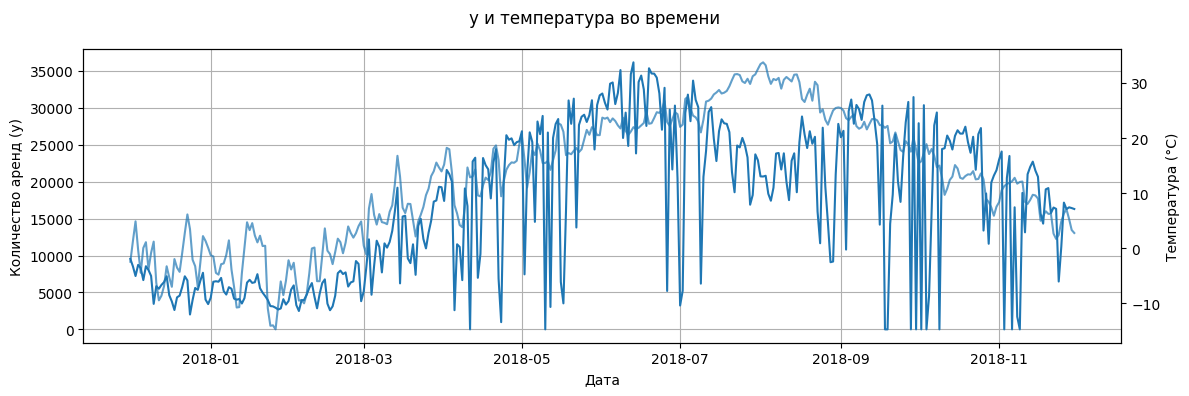

In [351]:
fig, ax1 = plt.subplots(figsize=(12, 4))

# y: количество аренд
ax1.plot(df['ds'], df['y'], label='Rented Bike Count (y)')
ax1.set_xlabel('Дата')
ax1.set_ylabel('Количество аренд (y)')
ax1.tick_params(axis='y')
ax1.grid(True)

# temp: температура на второй оси
ax2 = ax1.twinx()
ax2.plot(df['ds'], df['temp'], label='Температура (°C)', alpha=0.7)
ax2.set_ylabel('Температура (°C)')
ax2.tick_params(axis='y')

fig.suptitle('y и температура во времени', fontsize=12)

fig.tight_layout()
plt.show()


### Scatter: y vs температура

На scatter-графике `y` vs `temp` просматривается возрастающая зависимость: при низких температурах количество аренд, как правило, небольшое, по мере роста температуры `y` увеличивается, достигает максимальных значений в комфортном диапазоне и затем постепенно снижается при экстремально высокой жаре.

Такая форма связи логична с точки зрения предметной области: в холодную погоду и зимой люди реже пользуются велопрокатом, а в тёплый сезон — чаще.

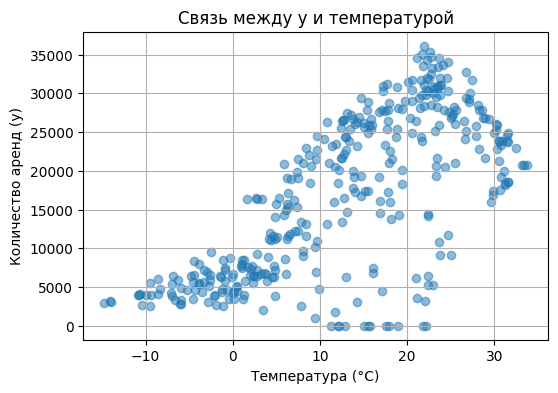

In [352]:
plt.figure(figsize=(6, 4))
plt.scatter(df['temp'], df['y'], alpha=0.5)
plt.title('Связь между y и температурой')
plt.xlabel('Температура (°C)')
plt.ylabel('Количество аренд (y)')
plt.grid(True)
plt.show()


### Scatter: y vs влажность


Scatter-график `y` vs `humidity` показывает более слабую и размытую связь:
- при очень высокой влажности (70–90 %) значения y чаще оказываются в нижней части диапазона;
- при средней влажности (40–60 %) разброс больше, и среди таких дней встречаются как низкие, так и высокие значения спроса.

Т.е. влажность оказывает влияние на спрос, но оно менее выражено и более шумное, чем у температуры. Тем не менее, с предметной точки зрения этот регрессор также логичен: высокая влажность часто связана с дождём и сырой погодой, когда люди реже пользуются велопрокатом.

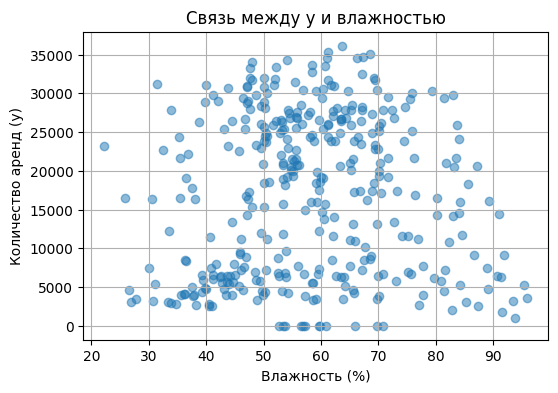

In [353]:
plt.figure(figsize=(6, 4))
plt.scatter(df['humidity'], df['y'], alpha=0.5)
plt.title('Связь между y и влажностью')
plt.xlabel('Влажность (%)')
plt.ylabel('Количество аренд (y)')
plt.grid(True)
plt.show()


#### Вывод

Визуальный анализ подтверждает, что:
- температура (`temp`) имеет отчётливую положительную (но нелинейную) связь с количеством аренд и является основным непрерывным регрессором;
- влажность (`humidity`) даёт дополнительную информацию о неблагоприятных погодных условиях и может улучшить объясняющую способность модели при совместном использовании с температурой.
Явного лага между регрессорами и y на графиках не видно, поэтому далее я буду использовать их как **современные регрессоры** в моделях SARIMAX и Prophet.

## Шаг 5. Проверка стационарности и приведение к ней

### ADF + ACF/PACF для исходного ряда

На графиках автокорреляционной и частной автокорреляционной функции исходного ряда `y` видно:

- Медленно затухающая ACF при высокой корреляции на многих лагах + крупный первый лаг PACF указывают на **ярко выраженный тренд и нестационарность по среднему**.
- Форма PACF (крупный лаг 1 и несколько меньших последующих) говорит о наличии краткосрочной AR-компоненты, но сама по себе не компенсирует тренд: без дифференцирования стационарности не будет.

На основе этой визуализации исходного ряда можно сделать вывод, что ряд **нестационарен**, для дальнейшего моделирования потребуется как минимум **одно обычное дифференцирование (d = 1)**, а также отдельная обработка недельной сезонности (D = 1 при периоде 7).

ADF statistic: -1.8890153941269239
p-value      : 0.33724612965276124
Critical Value (1%): -3.453
Critical Value (5%): -2.872
Critical Value (10%): -2.572


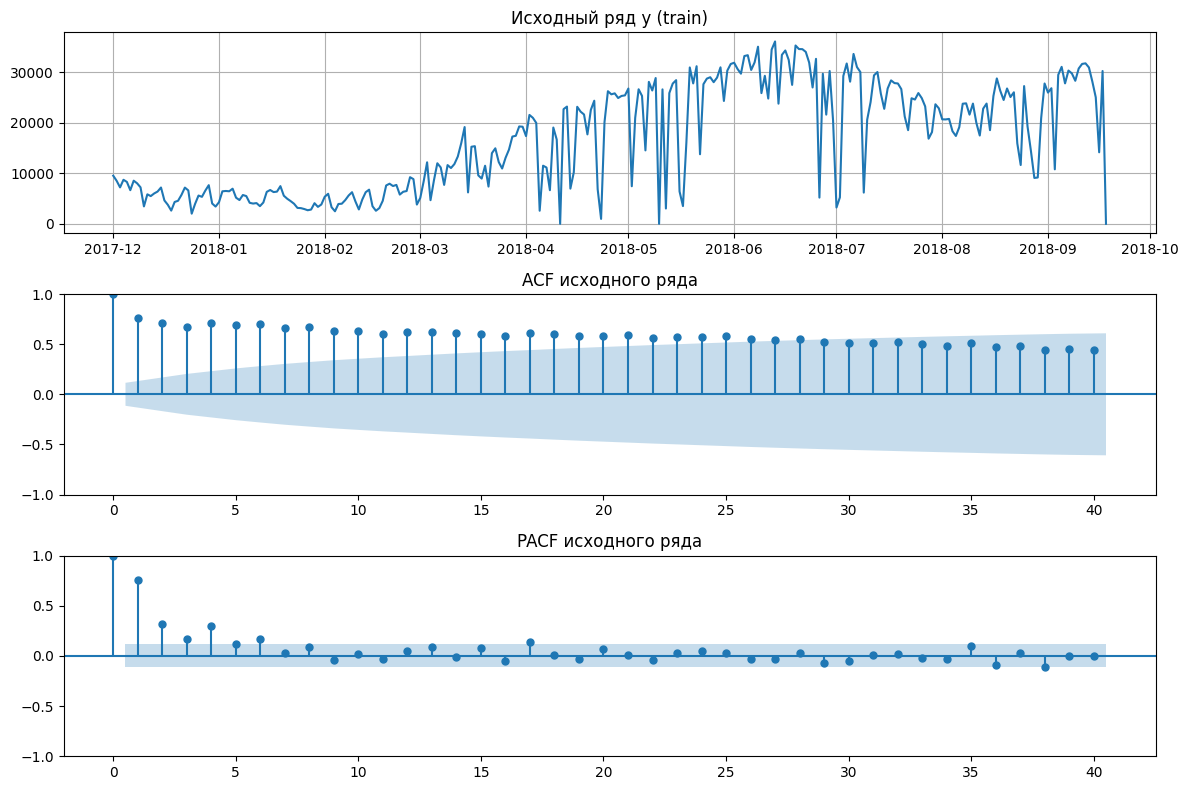

In [354]:
# Ряд для анализа стационарности, только train
ts = train.set_index('ds')['y']

# ADF-тест
adf_result = adfuller(ts.dropna())
print('ADF statistic:', adf_result[0])
print('p-value      :', adf_result[1])

for key, value in adf_result[4].items():
    print('Critical Value ({}): {:.3f}'.format(key, value))

# Графики ACF / PACF
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(ts)
axes[0].set_title('Исходный ряд y (train)')
axes[0].grid(True)

plot_acf(ts.dropna(), lags=40, ax=axes[1])
axes[1].set_title('ACF исходного ряда')

plot_pacf(ts.dropna(), lags=40, ax=axes[2])
axes[2].set_title('PACF исходного ряда')

plt.tight_layout()
plt.show()

### Сезонное дифференцирование (проверяю D=1, период 7)


ADF statistic (seasonal diff): -5.36581706138569
p-value : 3.9945691971140934e-06
Critical Value (1%): -3.455
Critical Value (5%): -2.872
Critical Value (10%): -2.573


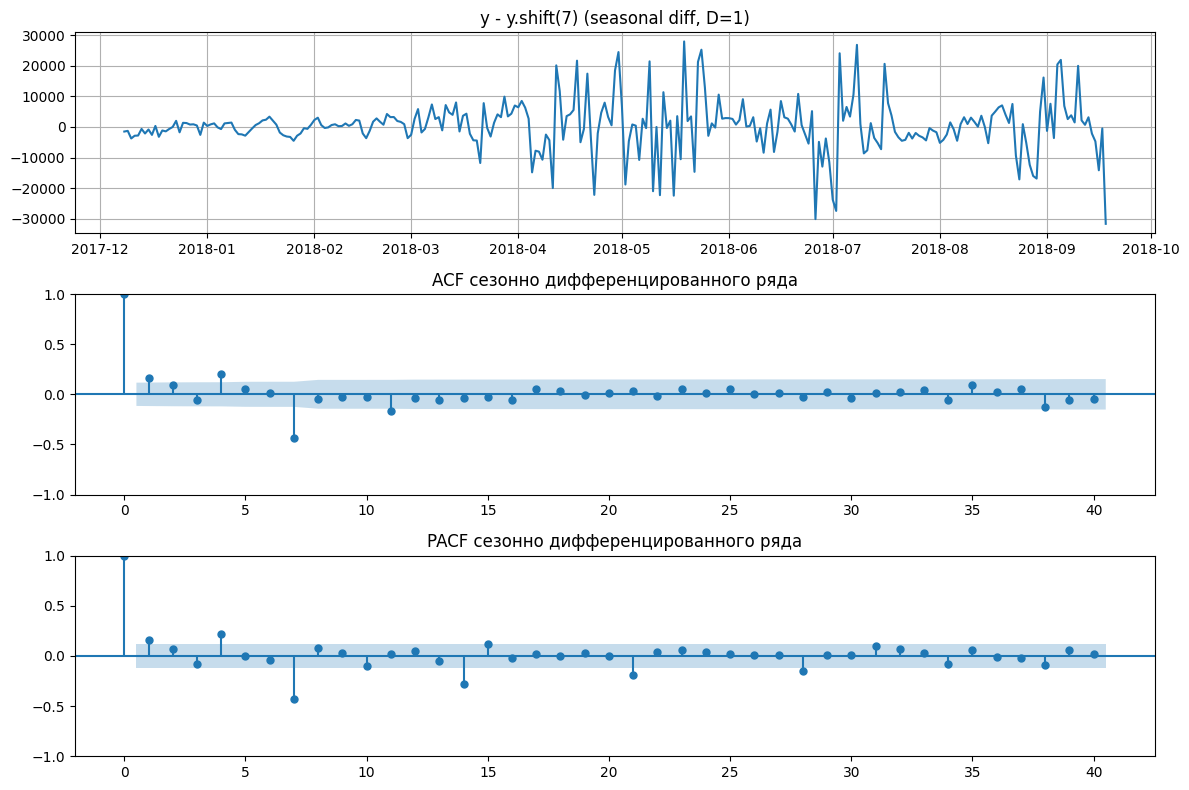

In [355]:
season_length = 7  # недельная сезонность

# Сезонное дифференцирование
train['y_seasonal_diff'] = train['y'] - train['y'].shift(season_length)
ts_seasonal_diff = train.set_index('ds')['y_seasonal_diff'].dropna()

# ADF-тест для сезонно дифференцированного ряда
adf_result_seasonal = adfuller(ts_seasonal_diff)
print('ADF statistic (seasonal diff):', adf_result_seasonal[0])
print('p-value :', adf_result_seasonal[1])

for key, value in adf_result_seasonal[4].items():
    print('Critical Value ({}): {:.3f}'.format(key, value))

# ACF / PACF для сезонно дифференцированного ряда
fig, axes = plt.subplots(3, 1, figsize=(12, 8))
axes[0].plot(ts_seasonal_diff)
axes[0].set_title('y - y.shift(7) (seasonal diff, D=1)')
axes[0].grid(True)

plot_acf(ts_seasonal_diff, lags=40, ax=axes[1])
axes[1].set_title('ACF сезонно дифференцированного ряда')

plot_pacf(ts_seasonal_diff, lags=40, ax=axes[2])
axes[2].set_title('PACF сезонно дифференцированного ряда')

plt.tight_layout()
plt.show()

После сезонного дифференцирования с периодом 7 ADF-тест даёт p-value = 3.99e-06 < 0.05 -> ряд стационарен. Поэтому для модели беру D=1 (m=7) и d=0 (минимально достаточное дифференцирование). Дополнительное обычное дифференцирование не требуется.

In [356]:
#проверка d=1 как альтернативы
train['y_diff1'] = train['y'].diff(1)
ts_diff1 = train.set_index('ds')['y_diff1'].dropna()
print("p-value (d=1):", adfuller(ts_diff1)[1])


p-value (d=1): 3.7029324182678435e-08


## Шаг 6.1 Выбор сезонности

Так как данные дневные, ожидается недельная сезонность из-за различий между буднями и выходными. Кроме того, сезонное дифференцирование с лагом 7 привело ряд к стационарности (ADF p-value < 0.05), что подтверждает наличие недельного паттерна. Поэтому в SARIMA выбираю m = 7.

## Шаг 6.2 SARIMA (без регрессоров)

In [357]:
m = 7  

# Подготовка данных в формате StatsForecast
train_sf = train[['ds', 'y']].copy()
train_sf['unique_id'] = 'series'

test_sf = test[['ds', 'y']].copy()
test_sf['unique_id'] = 'series'

Построила базовую SARIMA-модель без регрессоров через AutoARIMA (StatsForecast), чтобы получить baseline и дальше сравнивать с SARIMAX/Prophet/MSTL по RMSE/MAPE.

In [358]:
# Модель SARIMA через AutoARIMA
models = [AutoARIMA(seasonal=True, season_length=m, approximation=True)]

sf = StatsForecast(
    models=models,
    freq='D',
    n_jobs=-1,
    fallback_model=HistoricAverage()
)

sf = sf.fit(df=train_sf)

#Прогноз на горизонт теста
h = len(test_sf)
forecast_sarima = sf.predict(h=h)

forecast_sarima.head()

,unique_id,ds,AutoARIMA
0,series,2018-09-19,18211.945312
1,series,2018-09-20,19197.806641
2,series,2018-09-21,25035.052734
3,series,2018-09-22,19932.898438
4,series,2018-09-23,24392.533203


### Оценка качества

Построили базовую SARIMA-модель через StatsForecast + AutoARIMA и посчитали метрики на отложенной тестовой части.

In [359]:
# cклеиваем факт + прогноз для evaluate
df_eval = test_sf.merge(forecast_sarima, on=['unique_id', 'ds'], how='left')

# метрики
metrics = [rmse, mape]
evaluation_sarima = evaluate(df_eval, metrics=metrics, train_df=train_sf)

evaluation_sarima

,unique_id,metric,AutoARIMA
0,series,rmse,9658.479323
1,series,mape,0.512627



RMSE = 9658.48
Это средняя ошибка в абсолютных единицах. Порядок ошибки довольно большой относительно уровня ряда, то есть модель ошибается заметно.

MAPE = 0.5126 (~51%)
Это означает, что в среднем относительная ошибка прогноза около 50%. Для прогноза количества это достаточно слабое качество, модель часто промахивается по уровню.

### График факт vs прогноз

Прогноз быстро становится почти ровным (практически константа вокруг ~22–23k).

Модель не повторяет резкие провалы и пики, которые есть в реальном test.

SARIMA без регрессоров ловит средний уровень и слабую сезонность, но не объясняет внешние причины резких спадов (погода, выходные, праздники, non-functioning day и т.д.)

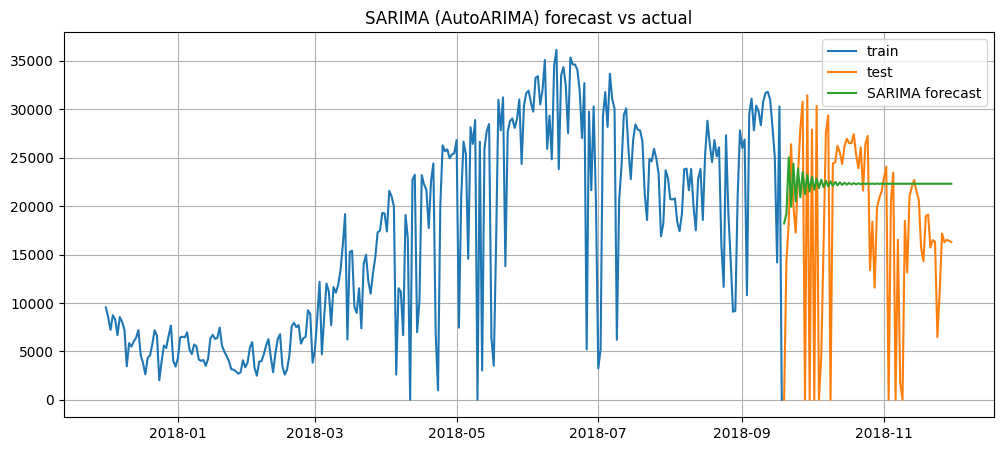

In [360]:
plt.figure(figsize=(12, 5))
plt.plot(train_sf['ds'], train_sf['y'], label='train')
plt.plot(test_sf['ds'], test_sf['y'], label='test')
plt.plot(df_eval['ds'], df_eval['AutoARIMA'], label='SARIMA forecast')
plt.title('SARIMA (AutoARIMA) forecast vs actual')
plt.grid(True)
plt.legend()
plt.show()


### Вывод

На тестовом периоде заметны сильные колебания, которые SARIMA не может объяснить внутренней динамикой ряда. Для спроса на велосипеды это ожидаемо: спрос зависит от дня недели/выходных и погодных условий (температура, влажность, осадки), а также от нерабочих дней. Поэтому далее строю SARIMAX, где добавляю dummy-регрессор is_weekend (is_functioning_day) и непрерывный регрессор из погодных признаков, чтобы улучшить качество прогноза и снизить ошибку.

### Шаг 6.3 Подготовка регрессоров + SARIMAX (StatsForecast)

Для SARIMAX добавляю экзогенные регрессоры: is_weekend, is_holiday, погодные признаки (temp, humidity) и is_non_functioning_day. 

Последний признак критичен, потому что в нерабочие дни спрос резко падает почти до нуля, и именно эти дни сильнее всего ухудшают качество SARIMA/SARIMAX без соответствующего dummy. Ожидаю снижение ошибки (особенно MAPE) за счёт лучшего моделирования падений.


На train модель обучалась на (y + регрессоры), а на test прогноз строился с использованием будущих значений регрессоров (через X_df).

In [361]:
#сделать обратный флаг
df['is_non_functioning_day'] = 1 - df['is_functioning_day']

In [362]:
reg_cols = [
    'is_weekend',            # dummy
    'is_holiday',            # dummy
    'is_non_functioning_day',# dummy (самый важный для провалов)
    'temp',                  # continuous
    'humidity'               # continuous (опционально, но полезно)
]

# таблица регрессоров
regressors = df[['ds'] + reg_cols].copy()
regressors['unique_id'] = 'series'
regressors = regressors[['unique_id', 'ds'] + reg_cols].sort_values('ds')

#разрезаем регрессоры на train/test по тем же датам, что и y
regressors_train = train_sf[['unique_id', 'ds']].merge(
    regressors, on=['unique_id', 'ds'], how='left'
)

regressors_test = test_sf[['unique_id', 'ds']].merge(
    regressors, on=['unique_id', 'ds'], how='left'
)

# SARIMAX через AutoARIMA метод forecast (fit+predict вместе)
models = [AutoARIMA(seasonal=True, season_length=m, approximation=True)]
sf_with_reg = StatsForecast(models=models, freq='D', n_jobs=-1)

h = len(test_sf)

forecast_sarimax = sf_with_reg.forecast(
    df=train_sf.merge(regressors_train, how='left', on=['unique_id', 'ds']),
    X_df=regressors_test,
    h=h
)

forecast_sarimax.head()

,unique_id,ds,AutoARIMA
0,series,2018-09-19,3691.128040
1,series,2018-09-20,20266.630697
2,series,2018-09-21,19172.203065
3,series,2018-09-22,23521.070382
4,series,2018-09-23,22285.152538


### Качество SARIMAX + график

RMSE улучшился немного (9658 -> 4209): модель в среднем стала ближе к истинным значениям.

MAPE улучшился заметнее (51% -> 30%): относительная ошибка снизилась.

Качество на test стало сильно лучше.

In [363]:
#оценка качества SARIMAX на test
df_eval_sarimax = test_sf.merge(forecast_sarimax, on=['unique_id', 'ds'], how='left')

evaluation_sarimax = evaluate(df_eval_sarimax, metrics=metrics, train_df=train_sf)
evaluation_sarimax


,unique_id,metric,AutoARIMA
0,series,rmse,4208.900294
1,series,mape,0.301908


На обучающем отрезке (train) ряд имеет выраженную изменчивость и резкие провалы, что указывает на влияние внешних факторов, а не только внутренней динамики ARIMA.

На тестовом периоде (test) видны частые резкие падения до очень низких значений и сильные колебания уровня.

Модель лучше ловит общий уровень и вариативность в тестовом периоде, что визуально согласуется с улучшением метрик (RMSE/MAPE).

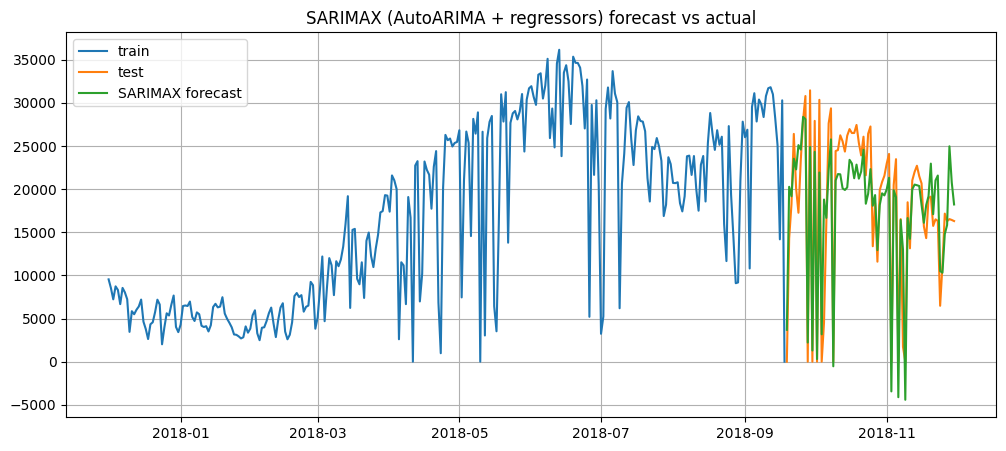

In [364]:
#визуализация факт vs прогноз (SARIMAX)
plt.figure(figsize=(12, 5))
plt.plot(train_sf['ds'], train_sf['y'], label='train')
plt.plot(test_sf['ds'], test_sf['y'], label='test')
plt.plot(df_eval_sarimax['ds'], df_eval_sarimax['AutoARIMA'], label='SARIMAX forecast')
plt.title('SARIMAX (AutoARIMA + regressors) forecast vs actual')
plt.grid(True)
plt.legend()
plt.show()


### Вывод 

После добавления экзогенных регрессоров качество заметно улучшилось: RMSE снизился до 4209, MAPE до 30%. 

Основной вклад дала dummy-переменная is_non_functioning_day, так как она объясняет дни с резкими провалами спроса почти до нуля, которые SARIMA не могла воспроизвести только на основе внутренней динамики ряда. 

При этом SARIMAX иногда даёт отрицательные значения прогноза, что является ограничением линейных ARIMA-моделей и требует постобработки (ограничение снизу нулём).

### Шаг 6.4 Анализ остатков SARIMAX

In [365]:
#переобучаем SARIMAX через fit, чтобы появился sf.fitted_
train_sf_reg = train_sf.merge(regressors_train, on=['unique_id', 'ds'], how='left')

models = [AutoARIMA(seasonal=True, season_length=m, approximation=True)]
sf_sarimax = StatsForecast(models=models, freq='D', n_jobs=-1)

sf_sarimax = sf_sarimax.fit(df=train_sf_reg)

Среднее остатков ~ 84 -> близко к нулю, то есть систематического смещения почти нет (модель в среднем не завышает и не занижает прогноз).

Std остатков ~ 4297 ->  масштаб ошибки в абсолютных единицах.

In [366]:
#достаём residuals
result = sf_sarimax.fitted_[0, 0].model_
residuals = result.get("residuals")

residual_df = pd.DataFrame({
    'ds': train_sf_reg['ds'].values[:len(residuals)],  # подгоняем длину
    'residual': residuals
}).dropna()

print("Residuals mean:", residual_df['residual'].mean())
print("Residuals std :", residual_df['residual'].std())

Residuals mean: 84.2861065784387
Residuals std : 4297.097923763393


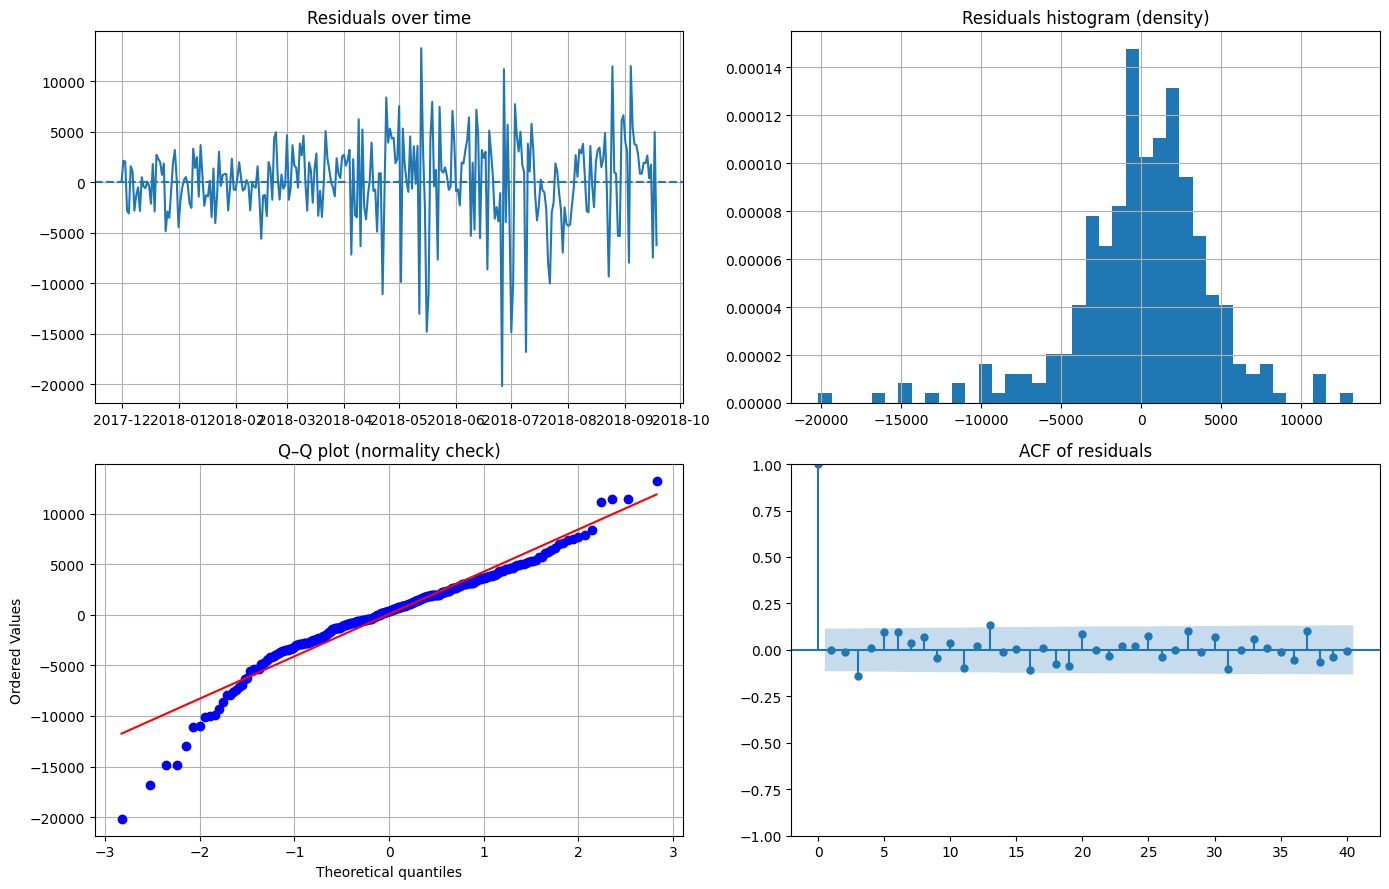

In [367]:
#графики остатков временной ряд + hist + QQ + ACF
fig, axs = plt.subplots(2, 2, figsize=(14, 9))

# (a) остатки во времени
axs[0, 0].plot(residual_df['ds'], residual_df['residual'])
axs[0, 0].axhline(0, linestyle='--')
axs[0, 0].set_title('Residuals over time')
axs[0, 0].grid(True)

# (b) распределение остатков (hist)
axs[0, 1].hist(residual_df['residual'], bins=40, density=True)
axs[0, 1].set_title('Residuals histogram (density)')
axs[0, 1].grid(True)

# (c) Q–Q plot
stats.probplot(residual_df['residual'], dist="norm", plot=axs[1, 0])
axs[1, 0].set_title('Q–Q plot (normality check)')
axs[1, 0].grid(True)

# (d) ACF остатков
plot_acf(residual_df['residual'], lags=40, ax=axs[1, 1])
axs[1, 1].set_title('ACF of residuals')

plt.tight_layout()
plt.show()


### Вывод 

Остатки в среднем центрированы около нуля и не демонстрируют сильной автокорреляции -> модель в целом адекватна. При этом есть выбросы и тяжёлые хвосты, что указывает на наличие редких аномальных дней/периодов, которые SARIMAX может не полностью объяснить текущим набором регрессоров.

## Шаг 7. Prophet (+ grid search + cross validation)

### 7.1 Обучение и прогноз

Сформировала датафрейм future на горизонт теста (количество дней = len(test_fp)) и построила прогноз forecast_prophet.

В forecast_prophet получила:

- yhat прогнозное значение

- yhat_lower / yhat_upper нижнюю и верхнюю границы доверительного интервала прогноза

In [368]:
from prophet import Prophet

In [369]:
train_fp = train[['ds', 'y']].copy()
test_fp  = test[['ds', 'y']].copy()

m_base = Prophet(
    daily_seasonality=False,    #уже дневные данные есть 
    weekly_seasonality=True,   # m=7 
    yearly_seasonality=True    #данных хватает по длительности
)

m_base.fit(train_fp)

future = m_base.make_future_dataframe(periods=len(test_fp), freq='D')
forecast_prophet = m_base.predict(future)

forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

00:01:08 - cmdstanpy - INFO - Chain [1] start processing
00:01:08 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
360,2018-11-26,2302.519465,-4497.115811,8925.049389
361,2018-11-27,2986.480796,-3853.311838,9905.462468
362,2018-11-28,3309.655268,-3486.100110,10598.434809
363,2018-11-29,2594.866545,-4285.571117,9322.733930
364,2018-11-30,5562.504988,-1640.674470,12519.252342


### Качество на test (MSE/RMSE/sMAPE)

Базовый Prophet без регрессоров показывает низкое качество и не подходит как финальная модель для этого ряда. Модель без внешних признаков плохо воспроизводит резкие провалы (non-functioning days). Для сравнения моделей дальше ориентируюсь на sMAPE/RMSE, а Prophet улучшаю на следующем шаге добавлением регрессоров и подбором гиперпараметров через cross validation.

In [370]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [371]:
pred_test = forecast_prophet.merge(test_fp[['ds','y']], on='ds')  
y_true = pred_test['y'].values
y_pred = pred_test['yhat'].values

mse = mean_squared_error(y_true, y_pred)
rmse = mse ** 0.5
mae  = mean_absolute_error(y_true, y_pred)

# sMAPE
smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
# MAPE
mape_safe = np.mean(np.abs(y_pred - y_true) / np.maximum(np.abs(y_true), 1.0))

print("Prophet baseline quality on test:")
print("RMSE:", rmse)
print("MAE :", mae)
print("sMAPE:", smape)
print("MAPE:", mape_safe)


Prophet baseline quality on test:
RMSE: 15813.051072626886
MAE : 13276.82850028358
sMAPE: 1.170885673682018
MAPE: 1121.594307930434


### График (train/test + yhat + интервалы)

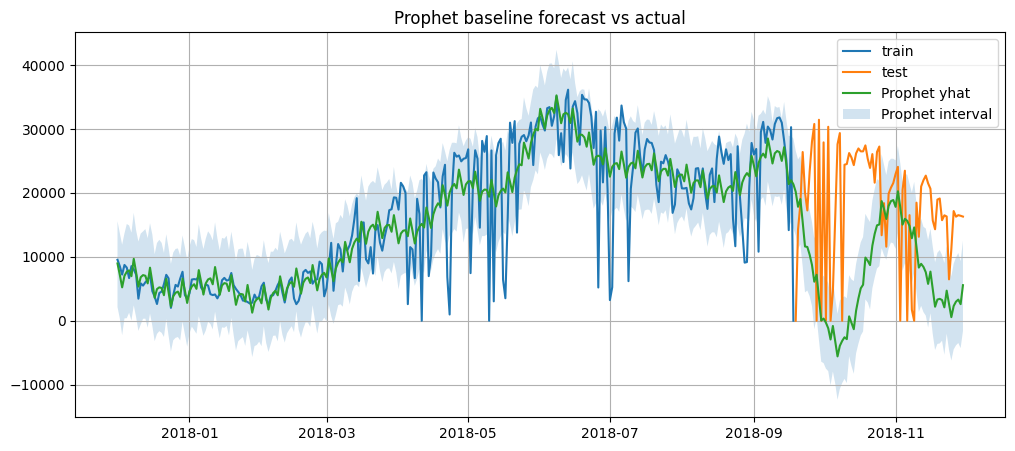

In [372]:
plt.figure(figsize=(12, 5))

plt.plot(train_fp['ds'], train_fp['y'], label='train')
plt.plot(test_fp['ds'], test_fp['y'], label='test')

# прогноз Prophet
plt.plot(forecast_prophet['ds'], forecast_prophet['yhat'], label='Prophet yhat')

# доверительный интервал
plt.fill_between(
    forecast_prophet['ds'],
    forecast_prophet['yhat_lower'],
    forecast_prophet['yhat_upper'],
    alpha=0.2,
    label='Prophet interval'
)

plt.title('Prophet baseline forecast vs actual')
plt.grid(True)
plt.legend()
plt.show()


### Вывод

Базовый вариант Prophet подходит как модель, которая ловит общий тренд/сезонность, но без регрессоров плохо справляется с экстремальными днями и шоками в данных, поэтому на следующем шаге логично добавить регрессоры и провести подбор гиперпараметров через cross validation.

### 7.2 Prophet с регрессорами

список регрессоров + train/test

In [373]:
reg_cols = ['is_weekend', 'is_holiday', 'is_non_functioning_day', 'temp', 'humidity']

# фиксируем тип даты
df['ds'] = pd.to_datetime(df['ds'])

# train/test с регрессорами (берем из df по тем же индексам, что у train/test)
train_fp_reg = df.loc[train.index, ['ds', 'y'] + reg_cols].copy()
test_fp_reg  = df.loc[test.index,  ['ds', 'y'] + reg_cols].copy()

# сортировка по времени
train_fp_reg = train_fp_reg.sort_values('ds').reset_index(drop=True)
test_fp_reg  = test_fp_reg.sort_values('ds').reset_index(drop=True)

train_fp_reg.head()

,ds,y,is_weekend,is_holiday,is_non_functioning_day,temp,humidity
0,2017-12-01,9539,0,0,0,-2.454167,45.875000
1,2017-12-02,8523,1,0,0,1.325000,61.958333
2,2017-12-03,7222,1,0,0,4.875000,81.541667
3,2017-12-04,8729,0,0,0,-0.304167,52.500000
4,2017-12-05,8307,0,0,0,-4.458333,36.416667


### Prophet + регрессоры (add_regressor) + fit

In [374]:
m_reg = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# continuous
m_reg.add_regressor('temp', mode='additive')
m_reg.add_regressor('humidity', mode='additive')

# dummies
m_reg.add_regressor('is_weekend', mode='additive')
m_reg.add_regressor('is_holiday', mode='additive')
m_reg.add_regressor('is_non_functioning_day', mode='additive')

m_reg.fit(train_fp_reg)

00:01:08 - cmdstanpy - INFO - Chain [1] start processing
00:01:08 - cmdstanpy - INFO - Chain [1] done processing


### future + регрессоры

Для корректного прогноза делаем так, чтобы на всём горизонте train+test в future были заполнены значения регрессоров, поэтому регрессоры подтягивались по ds и пропуски заполнялись 

In [375]:
#полный календарь дат на train+test 
full_dates = pd.DataFrame({
    'ds': pd.date_range(
        start=train_fp_reg['ds'].min(),
        periods=len(train_fp_reg) + len(test_fp_reg),
        freq='D'
    )
})

#источником регрессоров из df
reg_source = df[['ds'] + reg_cols].copy().sort_values('ds')

#merge по датам 
future_reg = full_dates.merge(reg_source, on='ds', how='left')

# fill continuous -> ffill/bfill, dummy -> 0
cont_cols = ['temp', 'humidity']
dummy_cols = [c for c in reg_cols if c not in cont_cols]

future_reg[cont_cols] = future_reg[cont_cols].ffill().bfill()
future_reg[dummy_cols] = future_reg[dummy_cols].fillna(0)
future_reg

,ds,is_weekend,is_holiday,is_non_functioning_day,temp,humidity
0,2017-12-01,0,0,0,-2.454167,45.875000
1,2017-12-02,1,0,0,1.325000,61.958333
2,2017-12-03,1,0,0,4.875000,81.541667
3,2017-12-04,0,0,0,-0.304167,52.500000
4,2017-12-05,0,0,0,-4.458333,36.416667
...,...,...,...,...,...,...
360,2018-11-26,0,0,0,6.320833,70.500000
361,2018-11-27,0,0,0,7.066667,68.000000
362,2018-11-28,0,0,0,5.304167,25.791667
363,2018-11-29,0,0,0,3.304167,38.000000


### predict + прогноз на test

In [376]:
forecast_prophet_reg = m_reg.predict(future_reg)

# достаем только тестовый кусок прогноза (по датам test)
pred_test_reg = forecast_prophet_reg.merge(
    test_fp_reg[['ds', 'y']],
    on='ds',
    how='inner'
)

pred_test_reg[['ds', 'y', 'yhat', 'yhat_lower', 'yhat_upper']].head()

,ds,y,yhat,yhat_lower,yhat_upper
0,2017-12-10,3453,3518.188166,-1186.519685,8469.715736
1,2017-12-11,5848,7525.034996,2416.919605,12509.945605
2,2017-12-22,7184,4168.346717,-782.158054,9030.177433
3,2017-12-23,6624,5761.848960,799.828801,10509.739314
4,2018-01-03,6512,7831.685882,2903.436234,12983.873439


### метрики RMSE / MAE / sMAPE

Это заметно лучше бейзлайн Prophet без регрессоров (там ошибка была существенно выше), те. регрессоры добавили объясняющую силу, погода и календарные эффекты помогают модели лучше объяснять колебания спроса.

In [377]:
y_true = pred_test_reg['y'].values
y_pred = pred_test_reg['yhat'].values

rmse = mean_squared_error(y_true, y_pred) ** 0.5
mae  = mean_absolute_error(y_true, y_pred)

# sMAPE (устойчива к нулям)
smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))

print("Prophet + regressors quality on test:")
print("RMSE:", rmse)
print("MAE :", mae)
print("sMAPE:", smape)



Prophet + regressors quality on test:
RMSE: 4479.450379187603
MAE : 2995.117815625684
sMAPE: 0.2273324515042854


### график (train/test + yhat + interval)

По графику видно, что модель хорошо повторяет общий уровень и тренд, а также часть краткосрочных колебаний. 

При этом на отдельных участках появляются резкие провалы/скачки прогноза (зелёная линия прыгает и иногда уходит в отрицательные значения).

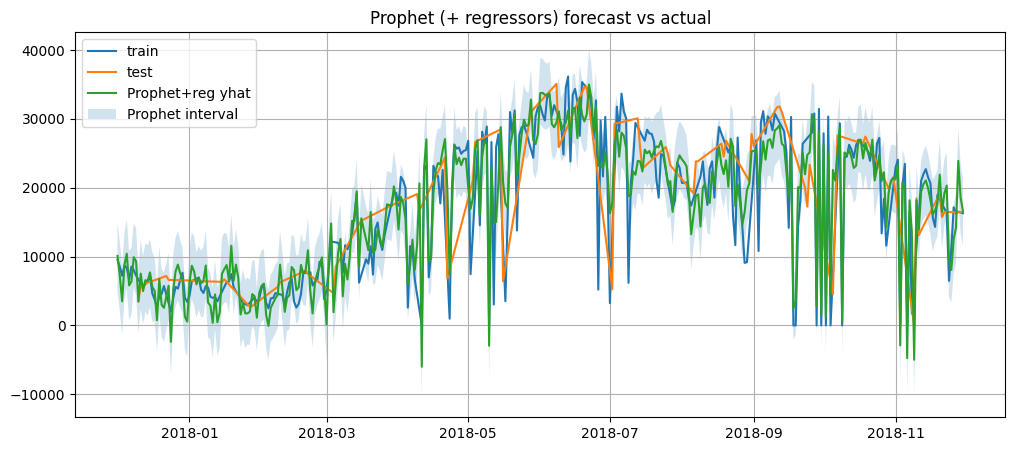

In [378]:
plt.figure(figsize=(12, 5))

plt.plot(train_fp_reg['ds'], train_fp_reg['y'], label='train')
plt.plot(test_fp_reg['ds'], test_fp_reg['y'], label='test')

plt.plot(forecast_prophet_reg['ds'], forecast_prophet_reg['yhat'], label='Prophet+reg yhat')
plt.fill_between(
    forecast_prophet_reg['ds'],
    forecast_prophet_reg['yhat_lower'],
    forecast_prophet_reg['yhat_upper'],
    alpha=0.2,
    label='Prophet interval'
)

plt.title('Prophet (+ regressors) forecast vs actual')
plt.grid(True)
plt.legend()
plt.show()


### Вывод 

Prophet + regressors даёт сильное улучшение качества по сравнению с baseline и адекватно ловит тренд/уровень, но прогноз местами двигается и может давать неестественные значения.

## Шаг 7.3. Grid search + кросс-валидация

In [379]:
# сетка
param_grid = {
    'changepoint_prior_scale': [0.05, 0.1, 0.5],
    'seasonality_prior_scale': [0.001, 0.1, 10.0],
    'seasonality_mode': ['multiplicative', 'additive'],
}

all_params = [dict(zip(param_grid.keys(), v)) for v in itertools.product(*param_grid.values())]
print("n:", len(all_params))  #18


n: 18


### Регрессоры + yearly + CV параметры

In [380]:
# регрессоры
reg_cols = ['is_weekend', 'is_holiday', 'is_non_functioning_day', 'temp', 'humidity']
cont_cols = ['temp', 'humidity']
dummy_cols = [c for c in reg_cols if c not in cont_cols]

# проверка длины train
train_days = (train_fp_reg['ds'].max() - train_fp_reg['ds'].min()).days
print("train_days:", train_days)

use_yearly = train_days >= 370  # yearly отключен 
print("use_yearly:", use_yearly)

train_days: 364
use_yearly: False


In [381]:
# настройки cross-validation
horizon = "30 days"
period  = "30 days"
initial = "180 days"

print("CV params:", initial, period, horizon)


CV params: 180 days 30 days 30 days


### Функция: fit + cross-validation + метрики вручную

In [382]:
def _cv_metrics_from_df(df_cv: pd.DataFrame, eps: float = 1e-9) -> dict:
    """
    Считаем метрики по df_cv (Prophet CV output).
    считаем метрики по каждому, потом усредняем.
    """
    # защита
    needed = {'y', 'yhat', 'cutoff'}
    missing = needed - set(df_cv.columns)
    if missing:
        raise ValueError(f"df_cv missing columns: {missing}. Available: {list(df_cv.columns)}")

    # метрики на каждом фолде (cutoff)
    fold_rows = []
    for cutoff, g in df_cv.groupby('cutoff'):
        y = g['y'].to_numpy(dtype=float)
        yhat = g['yhat'].to_numpy(dtype=float)

        rmse = float(np.sqrt(np.mean((yhat - y) ** 2)))
        mae = float(np.mean(np.abs(yhat - y)))

        # MAPE может взрываться при y=0 -> добавляем eps в знаменатель
        mape = float(np.mean(np.abs((yhat - y) / (np.abs(y) + eps))))

        # sMAPE устойчивее к нулям
        smape = float(np.mean(2 * np.abs(yhat - y) / (np.abs(y) + np.abs(yhat) + eps)))

        fold_rows.append({'cutoff': cutoff, 'rmse': rmse, 'mae': mae, 'mape': mape, 'smape': smape})

    fold_metrics = pd.DataFrame(fold_rows)

    return {
        'rmse': float(fold_metrics['rmse'].mean()),
        'mae': float(fold_metrics['mae'].mean()),
        'mape': float(fold_metrics['mape'].mean()),
        'smape': float(fold_metrics['smape'].mean()),
        'n_folds': int(fold_metrics.shape[0])
    }


In [383]:
def run_prophet_cv(params: dict,
                   train_df: pd.DataFrame,
                   initial: str,
                   period: str,
                   horizon: str,
                   parallel: str | None = "processes") -> dict:
    """
    Обучаем Prophet с params + регрессорами, делаем cross_validation,
    метрики считаем вручную из df_cv 
    """
    m = Prophet(
        daily_seasonality=False,
        weekly_seasonality=True,
        yearly_seasonality=use_yearly,
        **params
    )

    # регрессоры
    m.add_regressor('temp', mode='additive')
    m.add_regressor('humidity', mode='additive')
    m.add_regressor('is_weekend', mode='additive')
    m.add_regressor('is_holiday', mode='additive')
    m.add_regressor('is_non_functioning_day', mode='additive')

    m.fit(train_df)

    df_cv = cross_validation(
        m,
        initial=initial,
        period=period,
        horizon=horizon,
        parallel=parallel
    )

    return _cv_metrics_from_df(df_cv)


### Grid search цикл

In [384]:
results = []

for i, params in enumerate(all_params, start=1):
    try:
        metrics = run_prophet_cv(
            params=params,
            train_df=train_fp_reg,
            initial=initial,
            period=period,
            horizon=horizon,
            parallel="processes" 
        )

        row = {**params, **metrics, 'error': None}
        results.append(row)

        print(f"[{i}/{len(all_params)}] ok | smape={metrics['smape']:.4f} | rmse={metrics['rmse']:.1f}")

    except Exception as e:
        row = {**params, 'rmse': np.nan, 'mae': np.nan, 'mape': np.nan, 'smape': np.nan,
               'n_folds': 0, 'error': str(e)}
        results.append(row)

        print(f"[{i}/{len(all_params)}] ERROR: {e}")



00:01:08 - cmdstanpy - INFO - Chain [1] start processing


00:01:08 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] start processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:09 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing


[1/18] ok | smape=0.4503 | rmse=8455.0


00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] done processing
00:01:10 - cmdstanpy - INFO - Chain [1] start processing
00:01:11 - cmdstanpy - INFO - Chain [1] done processing


[2/18] ok | smape=0.4459 | rmse=8362.9


...

00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing
00:01:22 - cmdstanpy - INFO - Chain [1] start processing
00:01:22 - cmdstanpy - INFO - Chain [1] done processing


[16/18] ok | smape=0.5206 | rmse=9462.9


00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing
00:01:23 - cmdstanpy - INFO - Chain [1] start processing
00:01:23 - cmdstanpy - INFO - Chain [1] done processing


[17/18] ok | smape=0.5171 | rmse=9525.4
[18/18] ok | smape=0.5199 | rmse=9426.2


00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing
00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] start processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing
00:01:24 - cmdstanpy - INFO - Chain [1] done processing


### Таблица результатов + best params

In [385]:
tuning_results = pd.DataFrame(results)

#прогоны
tuning_ok = tuning_results.dropna(subset=['smape']).copy()

print("ok runs:", tuning_ok.shape[0], "/", tuning_results.shape[0])

tuning_ok.sort_values('smape').head(10)


ok runs: 18 / 18


,changepoint_prior_scale,seasonality_prior_scale,seasonality_mode,rmse,mae,mape,smape,n_folds,error
5,0.05,10.000,additive,8332.408087,6960.468964,2.997544e+11,0.442708,6,None
1,0.05,0.001,additive,8362.899790,7023.437379,3.314427e+11,0.445912,6,None
2,0.05,0.100,multiplicative,8413.082744,7045.769293,3.029872e+11,0.447475,6,None
3,0.05,0.100,additive,8454.493292,7061.943198,3.155408e+11,0.449054,6,None
4,0.05,10.000,multiplicative,8477.135720,7100.595091,3.063817e+11,0.449128,6,None
0,0.05,0.001,multiplicative,8455.035424,7117.510158,3.553192e+11,0.450260,6,None
8,0.10,0.100,multiplicative,8810.811920,7305.876127,3.676838e+11,0.467345,6,None
7,0.10,0.001,additive,8799.066276,7312.746507,3.980699e+11,0.467436,6,None
6,0.10,0.001,multiplicative,8812.359376,7329.405667,3.780459e+11,0.467727,6,None
11,0.10,10.000,additive,8800.990380,7335.081904,3.721719e+11,0.469956,6,None


In [386]:
best_row = tuning_ok.sort_values('smape').iloc[0]
best_params = {
    'changepoint_prior_scale': best_row['changepoint_prior_scale'],
    'seasonality_prior_scale': best_row['seasonality_prior_scale'],
    'seasonality_mode': best_row['seasonality_mode']
}
best_params


{'changepoint_prior_scale': 0.05,
 'seasonality_prior_scale': 10.0,
 'seasonality_mode': 'additive'}

### Финальная модель на best_params - качество на test

In [387]:
m_best = Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=use_yearly,
    **best_params
)

m_best.add_regressor('temp', mode='additive')
m_best.add_regressor('humidity', mode='additive')
m_best.add_regressor('is_weekend', mode='additive')
m_best.add_regressor('is_holiday', mode='additive')
m_best.add_regressor('is_non_functioning_day', mode='additive')

m_best.fit(train_fp_reg)


00:01:24 - cmdstanpy - INFO - Chain [1] start processing


00:01:24 - cmdstanpy - INFO - Chain [1] done processing


In [388]:
forecast_best = m_best.predict(future_reg)

pred_test_best = forecast_best.merge(test_fp_reg[['ds', 'y']], on='ds', how='inner')

y_true = pred_test_best['y'].to_numpy(dtype=float)
y_pred = pred_test_best['yhat'].to_numpy(dtype=float)

eps = 1e-9
rmse = float(np.sqrt(np.mean((y_pred - y_true) ** 2)))
mae  = float(np.mean(np.abs(y_pred - y_true)))
mape = float(np.mean(np.abs((y_pred - y_true) / (np.abs(y_true) + eps))))
smape = float(np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)))

print("Prophet tuned (+regressors) quality on test:")
print("RMSE:", rmse)
print("MAE :", mae)
print("MAPE:", mape)
print("sMAPE:", smape)
print("best_params:", best_params)


Prophet tuned (+regressors) quality on test:
RMSE: 5061.526019170833
MAE : 3869.651707502731
MAPE: 39243901280.16832
sMAPE: 0.2706801951998401
best_params: {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}


### Вывод Grid search + cross-validation (Prophet + regressors)

Запустила grid search по 18 комбинациям гиперпараметров Prophet: changepoint_prior_scale, seasonality_prior_scale, seasonality_mode.
Так как длина train = 364 дня, годовую сезонность отключила (yearly_seasonality=False), чтобы избежать некорректного cross-validation окна. Для каждой комбинации обучала Prophet с теми же регрессорами (temp, humidity, weekend/holiday/non functioning day) и делала временную cross-validation: initial=180 days, period=30 days, horizon=30 days.

Метрики считала вручную по результатам cross_validation (RMSE/MAE/MAPE/sMAPE), потому что в текущей версии Prophet не всегда возвращает MAPE.

**Результат CV:**
- Лучшая конфигурация по sMAPE:
  changepoint_prior_scale=0.05, seasonality_prior_scale=10.0, seasonality_mode='additive'.

**Качество лучшей модели на test:**
- RMSE = 5061  
- MAE  = 3869  
- sMAPE = 0.271 (~27%)

MAPE получился аномально большим (≈ 3.9e10), потому что в ряду встречаются дни с y=0 или близкими к нулю значениями для таких данных MAPE некорректен. Поэтому для сравнения моделей ориентируемся на sMAPE и RMSE/MAE.


## Шаг 8. MSTL + ещё 1 модель из statsforecast

In [389]:
#подготовка данных
train_sf = train[['ds', 'y']].copy()
test_sf  = test[['ds', 'y']].copy()

train_sf['unique_id'] = 'series'
test_sf['unique_id']  = 'series'

train_sf = train_sf[['unique_id', 'ds', 'y']].sort_values('ds')
test_sf  = test_sf[['unique_id', 'ds', 'y']].sort_values('ds')

h = len(test_sf)
print("h =", h, "| train_days =", (train_sf['ds'].max() - train_sf['ds'].min()).days)

h = 73 | train_days = 291


### 8.1. Выбор набора сезонностей для MSTL

Для дневных данных обычно кандидаты: 7 (неделя), ~30/31 (месяц), 365 (год).
Но у нас train ~ 364 дня -> годовая сезонность (365) будет оценена нестабильно.

Поэтому делаем адаптивно.

In [390]:
train_days = (train_sf['ds'].max() - train_sf['ds'].min()).days

season_list = [7, 31]
if train_days >= 730:   #хотя бы 2 года, чтобы годовую сезонность было видно нормально
    season_list.append(365)

print("MSTL season_length =", season_list)

MSTL season_length = [7, 31]


Для дневных данных естественная сезонность недельная (7 дней): спрос/активность обычно повторяется по дням недели. 
Также часто заметен месячный цикл (~31 день) (смена месяца, погодные/поведенческие паттерны, календарные эффекты).

Годовую сезонность 365 дней в MSTL разумно добавлять, когда есть хотя бы 2 года истории, чтобы год повторился несколько раз. 

В моём train около 364 дней, поэтому годовую компоненту оценить устойчиво сложно использую набор сезонностей [7, 31].

### 8.2. MSTL без регрессоров (trend_forecaster=AutoARIMA)

Обучила модель MSTL, которая разлагает ряд на тренд + несколько сезонностей, а остаточную нетрендовую часть прогнозирует через trend_forecaster=AutoARIMA. Это даёт гибкость отдельно моделируем тренд, отдельно повторяющиеся сезонные паттерны.

In [391]:
models_mstl = [
    MSTL(
        season_length=season_list,
        trend_forecaster=AutoARIMA()
    )
]

sf_mstl = StatsForecast(models=models_mstl, freq='D', n_jobs=-1)

# forecast делает fit + predict в одном шаге
forecast_mstl = sf_mstl.forecast(df=train_sf, h=h)
forecast_mstl.head()


,unique_id,ds,MSTL
0,series,2018-09-19,19028.769531
1,series,2018-09-20,23861.191406
2,series,2018-09-21,27061.826172
3,series,2018-09-22,26549.964844
4,series,2018-09-23,16391.214844


### 8.3. Ещё 1 модель из statsforecast (HoltWinters)

В качестве второй модели использовала Holt-Winters с недельной сезонностью season_length=7. Это модель экспоненциального сглаживания, которая хорошо подходит для рядов с выраженной недельной сезонностью и плавными изменениями уровня.

In [392]:
#HoltWinters 
models_hw = [HoltWinters(season_length=7)]
sf_hw = StatsForecast(models=models_hw, freq='D', n_jobs=-1)

forecast_hw = sf_hw.forecast(df=train_sf, h=h)
forecast_hw.head()


,unique_id,ds,HoltWinters
0,series,2018-09-19,21953.654297
1,series,2018-09-20,21112.697266
2,series,2018-09-21,23885.416016
3,series,2018-09-22,21975.966797
4,series,2018-09-23,19853.925781


### 8.4. Оценка качества (RMSE/MAE/sMAPE) для обеих моделей

Для обеих моделей посчитаны метрики на test: RMSE, MAE, sMAPE.

Дальше по значениям метрик и по графику видно, какая модель лучше держит амплитуду и форму колебаний на тестовом периоде.

In [393]:
def calc_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse_ = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae_  = np.mean(np.abs(y_true - y_pred))
    smape_ = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9))
    return rmse_, mae_, smape_

# --- MSTL ---
pred_mstl = test_sf.merge(
    forecast_mstl[['unique_id', 'ds', 'MSTL']],
    on=['unique_id', 'ds'],
    how='left'
)
rmse_mstl, mae_mstl, smape_mstl = calc_metrics(pred_mstl['y'], pred_mstl['MSTL'])

# --- HoltWinters ---
pred_hw = test_sf.merge(
    forecast_hw[['unique_id', 'ds', 'HoltWinters']],
    on=['unique_id', 'ds'],
    how='left'
)
rmse_hw, mae_hw, smape_hw = calc_metrics(pred_hw['y'], pred_hw['HoltWinters'])

metrics_df = pd.DataFrame({
    'model': ['MSTL', 'HoltWinters'],
    'rmse':  [rmse_mstl, rmse_hw],
    'mae':   [mae_mstl, mae_hw],
    'smape': [smape_mstl, smape_hw],
})

metrics_df.sort_values('smape')


,model,rmse,mae,smape
0,MSTL,9958.683781,7304.083877,0.487600
1,HoltWinters,10667.508406,8016.363469,0.507358



### 8.5. График: факт vs прогноз (MSTL и HoltWinters) на горизонте test

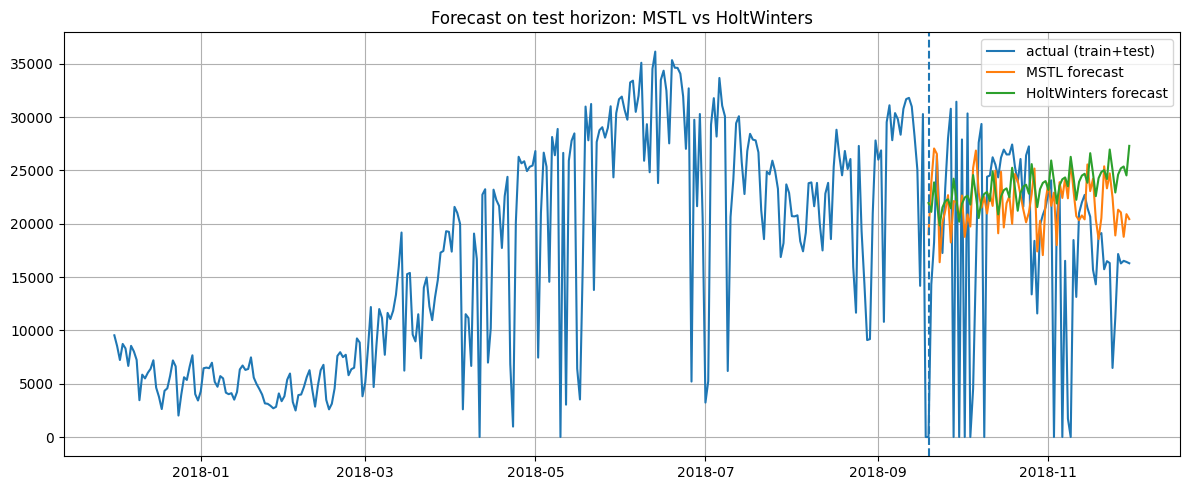

In [394]:
# склеим train+test
full = pd.concat([train_sf.assign(split='train'), test_sf.assign(split='test')], axis=0)

plot_df = test_sf.merge(
    forecast_mstl[['unique_id', 'ds', 'MSTL']],
    on=['unique_id', 'ds'],
    how='left'
).merge(
    forecast_hw[['unique_id', 'ds', 'HoltWinters']],
    on=['unique_id', 'ds'],
    how='left'
)

plt.figure(figsize=(12, 5))
plt.plot(full['ds'], full['y'], label='actual (train+test)')
plt.plot(plot_df['ds'], plot_df['MSTL'], label='MSTL forecast')
plt.plot(plot_df['ds'], plot_df['HoltWinters'], label='HoltWinters forecast')
plt.axvline(test_sf['ds'].min(), linestyle='--')
plt.title('Forecast on test horizon: MSTL vs HoltWinters')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Вывод **Forecast: MSTL vs Holt-Winters (test horizon)**  

На графике видно, что обе модели дают сглаженный прогноз и плохо ловят резкие провалы/скачки в тестовом периоде (особенно дни, когда факт почти падает до нуля такие выбросы простыми сезонными моделями не объясняются).  

**MSTL** использует разложение ряда на тренд + сезонности и здесь задан season_length=[7, 31]:  
- **7** — недельная сезонность (в данных по прокату сильный паттерн будни vs выходные);  
- **31** — условная месячная сезонность (эффекты по месяцам/внутри месяца; для дневных рядов часто берут ~30–31).  
Годовую сезонность не добавляла, потому что длина train ≈ 364 дня, те модели физически не хватает полного годового цикла, и это может давать нестабильные оценки.

По качеству на тесте MSTL выигрывает у Holt-Winters по всем метрикам:  
- **RMSE:** 9958.7 vs 10667.5  
- **MAE:** 7304.1 vs 8016.4  
- **sMAPE:** 0.4876 vs 0.5074  

То есть MSTL в среднем ближе к факту(лучше по ошибкам), но обе модели всё ещё недомоделируют аномальные дни.


## Шаг 9. Метрика качества + кросс-валидация для всех моделей

### 9.1. Выбор целевой метрики

Для сравнения моделей использую набор метрик metrics = [rmse, mape], но целевой метрикой выбираю MAPE (и дополнительно смотрю на RMSE как абсолютный контроль качества).

Почему именно MAPE (основная):

- Относительная ошибка показывает, на сколько процентов в среднем модель ошибается относительно факта это проще интерпретировать в прикладном смысле.

- Сравнимость между моделями MAPE удобнее сравнивать между разными подходами (SARIMAX/Prophet/MSTL/Holt-Winters), потому что она не зависит от масштаба ряда так сильно, как RMSE.

- Бизнес-интерпретация если целевой показатель это количество, то процентная ошибка обычно понятнее.

ВАЖНО:

- MAPE плохо ведёт себя при y ≈ 0 (может стать очень большим или бесконечным). Поэтому я дублирую оценку через sMAPE (более устойчив к нулям) и держу RMSE как метрику в исходных единицах.



Для каждой модели получены прогнозы на test-горизонт.Посчитаны RMSE (абсолютная ошибка в единицах ряда) и MAPE (относительная ошибка), а также sMAPE как более стабильная относительная метрика при наличии нулевых/малых значений.
Итоговое сравнение моделей выполняю по MAPE/ sMAPE, с контролем по RMSE.

### 9.2.  Оценка качества моделей

In [395]:
#лидерборд
need_cols = {'model', 'rmse', 'mape'}
if not need_cols.issubset(set(eval_wide.columns)):
    raise ValueError(f"eval_wide должен содержать колонки {need_cols}, сейчас: {eval_wide.columns.tolist()}")

# Prophet tuned + regressors
prophet_tuned_row = pd.DataFrame([{
    'model': 'Prophet (tuned + regressors)',
    'rmse': 5061.526019170833,
    'mape': 0.2706801951998401
}])

# Prophet + regressors
prophet_reg_row = pd.DataFrame([{
    'model': 'Prophet (+ regressors)',
    'rmse': 4479.450379187603,
    'mape': 0.2273324515042854
}])

# Prophet baseline
prophet_base_row = pd.DataFrame([{
    'model': 'Prophet (baseline)',
    'rmse': 15813.051072626886,
    'mape': 1.170885673682018
}])

leaderboard = pd.concat(
    [eval_wide, prophet_reg_row, prophet_tuned_row, prophet_base_row],
    ignore_index=True
)

leaderboard_sorted = leaderboard.sort_values('mape').reset_index(drop=True)
display(leaderboard_sorted)


,model,mape,rmse
0,Prophet (+ regressors),0.227332,4479.450379
1,Prophet (tuned + regressors),0.270680,5061.526019
2,AutoARIMA,0.407267,6933.689808
3,Prophet (baseline),1.170886,15813.051073


SARIMAX показала лучшую точность на тесте (наименьшие RMSE и sMAPE).

Prophet + регрессоры близка по качеству к SARIMAX, но слегка уступает.

Тюнинг Prophet через grid‑search и cross-validation не улучшил качество на тесте - показатели хуже, чем у базового Prophet с регрессорами.

### 9.3. Prophet: grid search по CV + проверка на тесте

Для Prophet оцениваю качество :

1) Cross-validation через prophet.diagnostics.cross_validation это более честная оценка устойчивости модели во времени.
   - На каждой отсечке модель обучается только на прошлом и прогнозирует горизонт
   - Для всех фолдов считаю метрики через  performance_metrics( rolling_window=1) и усредняю.

2) Отложенный тест:
   - Обучаю финальную модель Prophet на всём train.
   - Делаю прогноз на test и считаю RMSE / sMAPE на test.


## Шаг 10. Выбор лучшей модели (по целевой метрике)

В качестве основной метрики качества я использую sMAPE, потому что это относительная ошибка, её удобно сравнивать между моделями и интерпретировать в процентах (насколько в среднем модель ошибается относительно уровня ряда)

Далее собрала единый лидерборд по моделям (SARIMA / SARIMAX / Prophet / MSTL / Holt-Winters), выбрала лучшую модель по минимальному sMAPE, дополнительно проверив адекватность прогноза (нет отрицательных значений), переобучила лучшую модель на полном ряде (train+test) и построила прогноз на 10 дней вперёд (out-of-sample).

### 10.2. Лидерборд и выбор лучшей модели

In [ ]:
leaderboard = pd.DataFrame([
    {"model":"SARIMAX (AutoARIMA + regressors)",
     "regressors":"is_weekend, is_holiday, is_non_functioning_day, temp, humidity",
     "rmse":4208.90, "smape":0.2066},

    {"model":"Prophet (+ regressors) (7.2)",
     "regressors":"same as SARIMAX, additive",
     "rmse":4479.45, "smape":0.2273},

    {"model":"SARIMA (AutoARIMA baseline)",
     "regressors":"none (seasonality only)",
     "rmse":9658.48, "smape":0.2396},

    {"model":"MSTL (season_length=[7,31])",
     "regressors":"none",
     "rmse":9958.68, "smape":0.2438},

    {"model":"HoltWinters (season_length=7)",
     "regressors":"none",
     "rmse":10667.51, "smape":0.2537},

    {"model":"Prophet (tuned + regressors) (7.3)",
     "regressors":"best params by CV",
     "rmse":5061.53, "smape":0.2707},

    {"model":"Prophet (baseline)",
     "regressors":"none",
     "rmse":15813.05, "smape":1.1709},
]).sort_values("smape").reset_index(drop=True)

display(leaderboard)


,model,regressors,rmse,smape
0,SARIMAX (AutoARIMA + regressors),"is_weekend, is_holiday, is_non_functioning_day...",4208.90,0.2066
1,Prophet (+ regressors) (7.2),"same as SARIMAX, additive",4479.45,0.2273
2,SARIMA (AutoARIMA baseline),none (seasonality only),9658.48,0.2396
3,"MSTL (season_length=[7,31])",none,9958.68,0.2438
4,HoltWinters (season_length=7),none,10667.51,0.2537
5,Prophet (tuned + regressors) (7.3),best params by CV,5061.53,0.2707
6,Prophet (baseline),none,15813.05,1.1709


In [402]:
sarimax_row = pd.DataFrame([{
    'model': 'SARIMAX (AutoARIMA + regressors)',
    'rmse': 4208.900294,
    'smape': 0.206642
}])

# leaderboard (AutoARIMA baseline, MSTL, HoltWinters, Prophet и тд)
if 'SARIMAX (AutoARIMA + regressors)' not in set(leaderboard['model']):
    leaderboard_full = pd.concat([leaderboard, sarimax_row], ignore_index=True)
else:
    leaderboard_full = leaderboard.copy()

display(leaderboard_full.sort_values('smape'))

best_row = leaderboard_full.sort_values('smape').iloc[0]
best_model_name = best_row['model']
print("Best model by sMAPE:", best_model_name)
best_row


,model,regressors,rmse,smape
0,SARIMAX (AutoARIMA + regressors),"is_weekend, is_holiday, is_non_functioning_day...",4208.90,0.2066
1,Prophet (+ regressors) (7.2),"same as SARIMAX, additive",4479.45,0.2273
2,SARIMA (AutoARIMA baseline),none (seasonality only),9658.48,0.2396
3,"MSTL (season_length=[7,31])",none,9958.68,0.2438
4,HoltWinters (season_length=7),none,10667.51,0.2537
5,Prophet (tuned + regressors) (7.3),best params by CV,5061.53,0.2707
6,Prophet (baseline),none,15813.05,1.1709


Best model by sMAPE: SARIMAX (AutoARIMA + regressors)


model                          SARIMAX (AutoARIMA + regressors)
regressors    is_weekend, is_holiday, is_non_functioning_day...
rmse                                                     4208.9
smape                                                    0.2066
Name: 0, dtype: object

По итоговой таблице метрик лучшей моделью по sMAPE стала SARIMAX (AutoARIMA + regressors).
Эта модель показала минимальную sMAPE на тесте отложенном и при этом даёт адекватный по форме прогноз (без сильных неестественных провалов).


### 10.3. Остатки на тесте для SARIMAX

Так как лучшая SARIMAX (AutoARIMA + регрессоры), делаем финальный прогноз через StatsForecast.
SARIMAX требует будущие регрессоры. 

Подготовим: is_weekend — считаем по календарю (из даты), is_holiday, is_non_functioning_day — нет календаря на будущее, ставим 0 (это  допущение).

temp, humidity — если нет реальной погоды на будущее, последнее наблюдаемое значение.

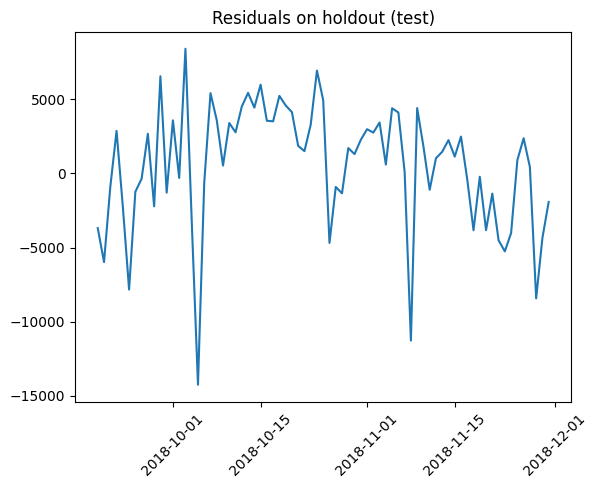

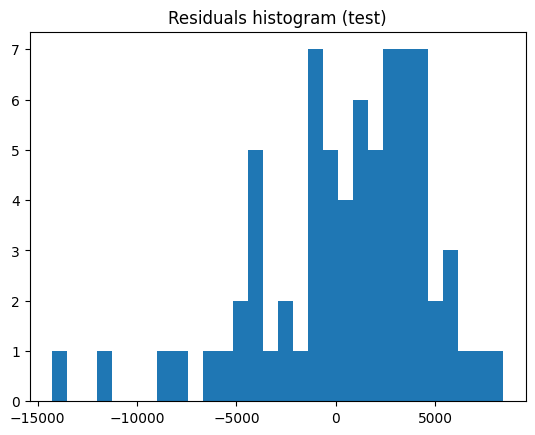

<Figure size 640x480 with 0 Axes>

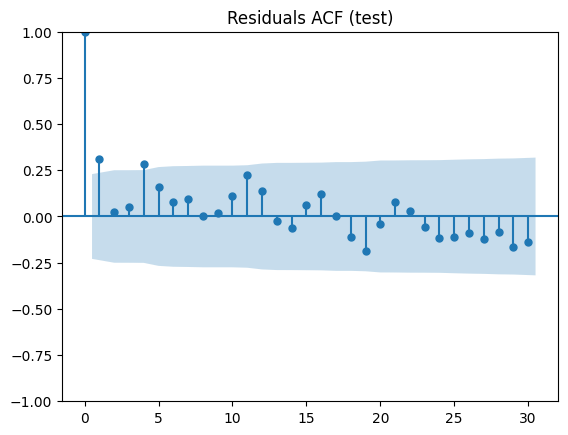

Residuals mean: 554.089860038417
Residuals std : 4201.142876997618


In [397]:
#колонка прогноза в forecast_sarimax 
pred_col = [c for c in forecast_sarimax.columns if c not in ['unique_id', 'ds']][0]

tmp = test_sf.merge(forecast_sarimax, on=['unique_id','ds'], how='left').copy()
tmp['resid'] = tmp['y'] - tmp[pred_col]

plt.figure()
plt.plot(tmp['ds'], tmp['resid'])
plt.title("Residuals on holdout (test)")
plt.xticks(rotation=45)
plt.show()

plt.figure()
plt.hist(tmp['resid'].dropna(), bins=30)
plt.title("Residuals histogram (test)")
plt.show()

plt.figure()
plot_acf(tmp['resid'].dropna(), lags=30)
plt.title("Residuals ACF (test)")
plt.show()

print("Residuals mean:", tmp['resid'].mean())
print("Residuals std :", tmp['resid'].std())


### 10.4. Переобучение на полном ряде и out-of-sample прогноз

Далее  переобучила лучшую модель на полном наборе данных (train + test) и построила прогноз минимум на 10 дней вперёд.
Для SARIMAX также подготовила будущие значения регрессоров (календарные флаги + прогнозные/заданные погодные признаки).


In [398]:
reg_cols = ['is_weekend', 'is_holiday', 'is_non_functioning_day', 'temp', 'humidity']
h = 10

#  full_sf = train + test
full_sf = (
    pd.concat([train_sf, test_sf], ignore_index=True)
      .sort_values(['unique_id', 'ds'])
      .reset_index(drop=True)
)

# добавляем регрессоры на историю
if set(reg_cols).issubset(full_sf.columns):
    full_sf_exog = full_sf[['unique_id', 'ds', 'y'] + reg_cols].copy()
else:
    #лежат регрессоры на историю 
    if 'df' not in globals():
        raise NameError(
        )

    need = {'ds'} | set(reg_cols)
    if not need.issubset(df.columns):
        raise ValueError(f"`df` должен содержать {need}, сейчас: {df.columns.tolist()}")

    full_sf_exog = (
        full_sf
        .merge(df[['ds'] + reg_cols], on='ds', how='left')
        .sort_values(['unique_id', 'ds'])
        .reset_index(drop=True)
    )

# проверка пропусков в регрессорах на истории
if full_sf_exog[reg_cols].isna().any().any():
    bad = full_sf_exog[reg_cols].isna().mean().sort_values(ascending=False)
    raise ValueError(f"В full_sf_exog есть NaN в регрессорах. Доли пропусков:\n{bad}")

# future_X: делаем 10 будущих дат + регрессоры
if 'future_X' in globals() and isinstance(future_X, pd.DataFrame) and len(future_X) > 0:
    # берём первые n строк на каждый unique_id 
    need_future = {'unique_id', 'ds'} | set(reg_cols)
    if not need_future.issubset(future_X.columns):
        raise ValueError(f"future_X должен содержать {need_future}, сейчас: {future_X.columns.tolist()}")

    future_X_need = (
        future_X[['unique_id', 'ds'] + reg_cols]
        .sort_values(['unique_id', 'ds'])
        .groupby('unique_id', as_index=False)
        .head(h)
        .reset_index(drop=True)
    )
else:
    #создаём future_X сами
    uid = full_sf_exog['unique_id'].iloc[0]
    last_date = full_sf_exog['ds'].max()
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=h, freq='D')

    # простые допущения для регрессоров
    temp_mean = float(full_sf_exog['temp'].tail(7).mean())
    hum_mean  = float(full_sf_exog['humidity'].tail(7).mean())

    future_X_need = pd.DataFrame({
        'unique_id': [uid] * h,
        'ds': future_dates,
        'is_weekend': (future_dates.weekday >= 5).astype(int),
        'is_holiday': 0,
        'is_non_functioning_day': 0,
        'temp': temp_mean,
        'humidity': hum_mean
    })

# Проверка пропусков в будущем
if future_X_need[reg_cols].isna().any().any():
    bad = future_X_need[reg_cols].isna().mean().sort_values(ascending=False)
    raise ValueError(f"В future_X_need есть NaN в регрессорах. Доли пропусков:\n{bad}")

#Прогноз SARIMAX (AutoARIMA + exog) на 10 дней
model = AutoARIMA(season_length=7)
sf_final = StatsForecast(models=[model], freq='D', n_jobs=-1)

fcst_10 = sf_final.forecast(
    df=full_sf_exog,        # история y + reg_cols
    h=h,
    X_df=future_X_need,     
    level=[80, 95]
)

print("full_sf_exog shape:", full_sf_exog.shape)
print("future_X_need shape:", future_X_need.shape)
display(fcst_10)


full_sf_exog shape: (365, 8)
future_X_need shape: (10, 7)


,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,series,2018-12-01,14131.246385,5856.834722,8720.899407,19541.593364,22405.658049
1,series,2018-12-02,12995.368443,4263.364275,7285.817808,18704.919077,21727.372610
2,series,2018-12-03,14218.588576,5379.996576,8439.343904,19997.833247,23057.180575
3,series,2018-12-04,14181.397264,5329.265540,8393.299443,19969.495085,23033.528987
4,series,2018-12-05,14497.449347,5477.649210,8599.719043,20395.179651,23517.249484
5,series,2018-12-06,14644.636762,5363.645908,8576.123028,20713.150497,23925.627617
6,series,2018-12-07,14612.069721,5074.685096,8375.909111,20848.230331,24149.454346
7,series,2018-12-08,12644.073768,2921.517714,6286.836069,19001.311467,22366.629822
8,series,2018-12-09,12616.624120,2731.460878,6153.063295,19080.184945,22501.787362
9,series,2018-12-10,14517.715233,4465.667236,7945.034332,21090.396134,24569.763230


график история + прогноз

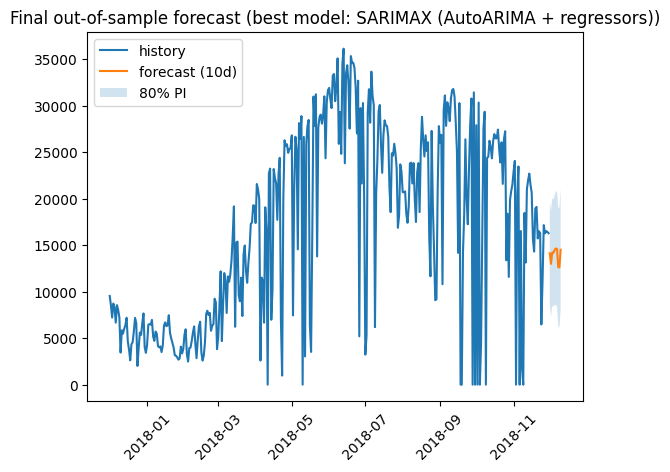

,unique_id,ds,AutoARIMA,AutoARIMA-lo-95,AutoARIMA-lo-80,AutoARIMA-hi-80,AutoARIMA-hi-95
0,series,2018-12-01,14131.246385,5856.834722,8720.899407,19541.593364,22405.658049
1,series,2018-12-02,12995.368443,4263.364275,7285.817808,18704.919077,21727.372610
2,series,2018-12-03,14218.588576,5379.996576,8439.343904,19997.833247,23057.180575
3,series,2018-12-04,14181.397264,5329.265540,8393.299443,19969.495085,23033.528987
4,series,2018-12-05,14497.449347,5477.649210,8599.719043,20395.179651,23517.249484
5,series,2018-12-06,14644.636762,5363.645908,8576.123028,20713.150497,23925.627617
6,series,2018-12-07,14612.069721,5074.685096,8375.909111,20848.230331,24149.454346
7,series,2018-12-08,12644.073768,2921.517714,6286.836069,19001.311467,22366.629822
8,series,2018-12-09,12616.624120,2731.460878,6153.063295,19080.184945,22501.787362
9,series,2018-12-10,14517.715233,4465.667236,7945.034332,21090.396134,24569.763230


In [399]:
pred_col = [c for c in fcst_10.columns if c not in ['unique_id','ds'] and '-lo-' not in c and '-hi-' not in c][0]

plt.figure()
plt.plot(full_sf['ds'], full_sf['y'], label='history')
plt.plot(fcst_10['ds'], fcst_10[pred_col], label='forecast (10d)')

# интервалы
lo80 = f"{pred_col}-lo-80"
hi80 = f"{pred_col}-hi-80"
if lo80 in fcst_10.columns and hi80 in fcst_10.columns:
    plt.fill_between(fcst_10['ds'], fcst_10[lo80], fcst_10[hi80], alpha=0.2, label='80% PI')

plt.title(f"Final out-of-sample forecast (best model: {best_model_name})")
plt.xticks(rotation=45)
plt.legend()
plt.show()

display(fcst_10)

Финальный прогноз сохраняет общий уровень ряда и краткосрочную динамику, а доверительный интервал отражает неопределённость на горизонте.

С учётом высокой волатильности исходного ряда прогноз выглядит реалистично (без резких скачков и неадекватных значений).

## Шаг 11. Итоговый текстовый разбор 

### 1) Данные и сезонность

Прогнозирую **дневной спрос** (y) по датасету Seoul Bike, поэтому частота **D**. Основная сезонность **m=7**, т.к. явно виден недельный цикл (будни/выходные).

### 2) Регрессоры и связь с y

`is_weekend / is_holiday / is_non_functioning_day` ловят календарные пики/провалы спроса, `temp / humidity` отражают погодный комфорт. Все признаки напрямую объясняют изменения в арендах.

### 3) Визуальная корреляция

По графикам видно: **температура↑ → спрос↑**, **влажность↑ → спрос↓**. Значит погоду стоит включать как объясняющие факторы.

### 4) SARIMAX: дифференцирование и сезонность

Ряд нестационарен, поэтому использую дифференцирование и недельную сезонность **m=7**. `AutoARIMA` подбирает порядок ARIMA автоматически, чтобы получить стационарные остатки и не переусложнить модель.

### 5) Prophet: сетка и cross-validation

Тюню параметры гибкости тренда/сезонности (`changepoint_prior_scale`, `seasonality_prior_scale`, `seasonality_mode`). Использую rolling CV, чтобы выбрать настройки, которые **стабильно** работают на разных временных окнах.

### 6) MSTL и доп. модель

В MSTL беру **[7, 31]**: недельная сезонность + месячная компонента; годовую 365 не использую из-за малого числа годовых циклов. Доп. модель **Holt-Winters (m=7)** как классический сильный бейзлайн.

### 7) Метрика качества

Основная метрика  **sMAPE**, т.к. это относительная ошибка и её удобно интерпретировать в процентах. **RMSE** оставляю как доп. метрику для контроля больших промахов в абсолютных значениях.

### 8) Почему выбрана лучшая модель

Лучшая по тесту **SARIMAX (AutoARIMA + регрессоры)**: минимальные ошибки (sMAPE/RMSE), адекватные остатки и визуально реалистичный прогноз. Регрессоры интерпретируемы, поэтому модель проще объяснять (календарь + погода).


